#Kaggle

## Mô tả dữ liệu


In [ ]:
# Cell mô tả dữ liệu 1: Cấu hình đường dẫn Kaggle và đọc JSONL
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

# Đường dẫn đang có trong notebook của bạn
DATA_ROOT = Path("/kaggle/input/datasets/vietnguyencong123/dataset-ppnckh")

DATASETS = {
    "vimedner": {
        "train": DATA_ROOT / "vimedner" / "train_fixed_verified.jsonl",
        "dev": DATA_ROOT / "vimedner" / "dev_fixed_verified.jsonl",
        "test": DATA_ROOT / "vimedner" / "test_fixed_verified.jsonl",
        "labels": ("DISEASE", "SYMPTOM", "TREATMENT", "CAUSE", "DIAGNOSTIC"),
        "description": "Văn bản y tế tổng quát",
    },
    "vimq": {
        "train": DATA_ROOT / "vimq" / "train_fixed_verified.jsonl",
        "dev": DATA_ROOT / "vimq" / "dev_fixed_verified.jsonl",
        "test": DATA_ROOT / "vimq" / "test_fixed_verified.jsonl",
        "labels": ("SYMPTOM_AND_DISEASE", "MEDICAL_PROCEDURE", "DRUG"),
        "description": "Câu hỏi y tế",
    },
}

SPLITS = ("train", "dev", "test")
LANGS = ("vi", "en")

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def count_tokens(text):
    return len(str(text or "").split())

def entity_span_len(entity, lang):
    try:
        start = int(entity.get(f"{lang}_start_token_idx"))
        end = int(entity.get(f"{lang}_end_token_idx"))
    except (TypeError, ValueError):
        return np.nan
    return end - start + 1 if end >= start else np.nan

path_rows = []
for dataset_name, cfg in DATASETS.items():
    for split in SPLITS:
        path = cfg[split]
        path_rows.append({
            "dataset": dataset_name,
            "split": split,
            "path": str(path),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024 / 1024, 2) if path.exists() else np.nan,
        })

path_df = pd.DataFrame(path_rows)

display(Markdown("## Kiểm tra đường dẫn dữ liệu"))
display(path_df)

## Kiểm tra đường dẫn dữ liệu

,dataset,split,path,exists,size_mb
0,vimedner,train,/kaggle/input/datasets/vietnguyencong123/datas...,True,3.93
1,vimedner,dev,/kaggle/input/datasets/vietnguyencong123/datas...,True,1.33
2,vimedner,test,/kaggle/input/datasets/vietnguyencong123/datas...,True,1.31
3,vimq,train,/kaggle/input/datasets/vietnguyencong123/datas...,True,3.56
4,vimq,dev,/kaggle/input/datasets/vietnguyencong123/datas...,True,0.51
5,vimq,test,/kaggle/input/datasets/vietnguyencong123/datas...,True,0.53


In [ ]:
# Cell mô tả dữ liệu 2: Tạo bảng thống kê tổng quan
summary_rows = []
label_rows = []
length_rows = []
span_rows = []
term_rows = []
sample_rows = []

for dataset_name, cfg in DATASETS.items():
    for split in SPLITS:
        rows = read_jsonl(cfg[split])

        total_entities = 0
        empty_samples = 0
        vi_lengths = []
        en_lengths = []

        for row_idx, row in enumerate(rows):
            entities = row.get("entities", []) or []
            total_entities += len(entities)
            empty_samples += int(len(entities) == 0)

            vi_len = count_tokens(row.get("vi_sentence_str"))
            en_len = count_tokens(row.get("en_sentence_str"))

            vi_lengths.append(vi_len)
            en_lengths.append(en_len)

            for lang, token_len in (("vi", vi_len), ("en", en_len)):
                length_rows.append({
                    "dataset": dataset_name,
                    "split": split,
                    "language": lang,
                    "tokens": token_len,
                    "entities": len(entities),
                })

            for entity in entities:
                label = entity.get("label", "UNKNOWN")

                label_rows.append({
                    "dataset": dataset_name,
                    "split": split,
                    "label": label,
                    "count": 1,
                })

                for lang in LANGS:
                    term = str(entity.get(f"{lang}_term") or "").strip()
                    span_rows.append({
                        "dataset": dataset_name,
                        "split": split,
                        "language": lang,
                        "label": label,
                        "entity_tokens": entity_span_len(entity, lang),
                    })
                    term_rows.append({
                        "dataset": dataset_name,
                        "split": split,
                        "language": lang,
                        "label": label,
                        "term": term,
                    })

            if split == "train" and row_idx < 3:
                entity_text = "; ".join(
                    f"{e.get('label')}: {e.get('vi_term')} / {e.get('en_term')}"
                    for e in entities[:5]
                )
                sample_rows.append({
                    "dataset": dataset_name,
                    "vi_sentence": row.get("vi_sentence_str", ""),
                    "en_sentence": row.get("en_sentence_str", ""),
                    "entities": entity_text if entity_text else "(none)",
                })

        summary_rows.append({
            "dataset": dataset_name,
            "split": split,
            "samples": len(rows),
            "sft_records_vi_en": sum(
                1 for row in rows for lang in LANGS if row.get(f"{lang}_sentence_str")
            ),
            "entities": total_entities,
            "empty_samples": empty_samples,
            "avg_entities_per_sample": total_entities / len(rows) if rows else 0,
            "avg_vi_tokens": np.mean(vi_lengths) if vi_lengths else 0,
            "avg_en_tokens": np.mean(en_lengths) if en_lengths else 0,
        })

summary_df = pd.DataFrame(summary_rows)
label_df = pd.DataFrame(label_rows).groupby(
    ["dataset", "split", "label"], as_index=False
)["count"].sum()
length_df = pd.DataFrame(length_rows)
span_df = pd.DataFrame(span_rows)
term_df = pd.DataFrame(term_rows)
sample_df = pd.DataFrame(sample_rows)

display(Markdown("## Bảng tổng quan dữ liệu"))
display(
    summary_df.style
    .format({
        "samples": "{:,.0f}",
        "sft_records_vi_en": "{:,.0f}",
        "entities": "{:,.0f}",
        "empty_samples": "{:,.0f}",
        "avg_entities_per_sample": "{:.2f}",
        "avg_vi_tokens": "{:.1f}",
        "avg_en_tokens": "{:.1f}",
    })
    .background_gradient(
        subset=["samples", "entities", "avg_entities_per_sample", "avg_vi_tokens", "avg_en_tokens"],
        cmap="Blues",
    )
)

display(Markdown("## Nhận xét nhanh"))
for dataset_name in DATASETS:
    ds_summary = summary_df[summary_df["dataset"] == dataset_name]
    ds_labels = label_df[label_df["dataset"] == dataset_name]

    top = ds_labels.groupby("label")["count"].sum().sort_values(ascending=False)
    top_label = top.index[0]
    top_count = int(top.iloc[0])

    total_samples = int(ds_summary["samples"].sum())
    total_entities = int(ds_summary["entities"].sum())
    total_empty = int(ds_summary["empty_samples"].sum())

    avg_vi = np.average(ds_summary["avg_vi_tokens"], weights=ds_summary["samples"])
    avg_en = np.average(ds_summary["avg_en_tokens"], weights=ds_summary["samples"])

    display(Markdown(
        f"**{dataset_name}** có **{total_samples:,}** cặp câu song ngữ, "
        f"**{total_entities:,}** entity được gán nhãn. "
        f"Nhãn nhiều nhất là `{top_label}` với **{top_count:,}** entity. "
        f"Độ dài trung bình khoảng **{avg_vi:.1f}** token tiếng Việt và "
        f"**{avg_en:.1f}** token tiếng Anh. "
        f"Có **{total_empty:,}** mẫu không có entity."
    ))

display(Markdown("## Ví dụ annotation trong train split"))
display(
    sample_df.style.set_properties(
        subset=["vi_sentence", "en_sentence", "entities"],
        **{"white-space": "pre-wrap"},
    )
)

## Bảng tổng quan dữ liệu

,dataset,split,samples,sft_records_vi_en,entities,empty_samples,avg_entities_per_sample,avg_vi_tokens,avg_en_tokens
0,vimedner,train,"4,576","9,152","11,709",0,2.56,36.5,27.2
1,vimedner,dev,"1,524","3,048","3,977",1,2.61,36.8,27.5
2,vimedner,test,"1,525","3,050","3,947",0,2.59,36.3,27.0
3,vimq,train,"7,000","14,000","11,926",175,1.70,14.2,12.8
4,vimq,dev,"1,000","2,000","1,725",19,1.73,14.2,12.8
5,vimq,test,"1,000","2,000","1,776",16,1.78,14.7,13.3


## Nhận xét nhanh

**vimedner** có **7,625** cặp câu song ngữ, **19,633** entity được gán nhãn. Nhãn nhiều nhất là `DISEASE` với **9,385** entity. Độ dài trung bình khoảng **36.5** token tiếng Việt và **27.2** token tiếng Anh. Có **1** mẫu không có entity.

**vimq** có **9,000** cặp câu song ngữ, **15,427** entity được gán nhãn. Nhãn nhiều nhất là `SYMPTOM_AND_DISEASE` với **12,377** entity. Độ dài trung bình khoảng **14.3** token tiếng Việt và **12.8** token tiếng Anh. Có **210** mẫu không có entity.

## Ví dụ annotation trong train split

,dataset,vi_sentence,en_sentence,entities
0,vimedner,các khối u não xảy ra thường xuyên hơn ở người da trắng hơn là ở người của các chủng tộc khác .,Brain tumors occur more frequently in Caucasians than in people of other races .,DISEASE: khối u não / Brain tumors
1,vimedner,"biến chứng có thể gặp khi mắc sởi nếu không được phát hiện và can thiệp kịp thời , có thể gây ra các biến chứng nguy hiểm : tiêu chảy là biến chứng thường gặp nhất , tiêu chảy do bệnh sởi có thể dẫn đến tình trạng dinh dưỡng giảm sút .","Complications can occur with measles if not detected and treated promptly , which can lead to dangerous complications : diarrhea is the most common complication , and diarrhea due to measles can lead to malnutrition .",DISEASE: sởi / measles; DISEASE: bệnh sởi / measles
2,vimedner,"tác động của viêm ruột thừa cấp đối với sức khỏe đau bụng : khi bị viêm ruột thừa cấp , người bệnh đau bụng bắt đầu lan tỏa ở vùng thượng vị và vùng rốn , sau đó chuyển sang phía dưới , bên phải của vùng bụng .","The impact of acute appendicitis on health includes abdominal pain : when suffering from acute appendicitis , the patient ' s abdominal pain begins diffusely in the epigastric and umbilical regions , then moves to the lower right side of the abdomen .",DISEASE: viêm ruột thừa cấp / acute appendicitis; SYMPTOM: đau bụng / abdominal pain; DISEASE: viêm ruột thừa cấp / acute appendicitis; SYMPTOM: đau bụng / abdominal pain
3,vimq,Hẹp động mạch thận phải có tiến hành hiến thận được không ?,Can a kidney donation be performed with right renal artery stenosis ?,SYMPTOM_AND_DISEASE: Hẹp động mạch thận / renal artery stenosis; MEDICAL_PROCEDURE: hiến thận / kidney donation
4,vimq,"Trẻ sơ sinh 2 tháng tuổi vàng mặt , hay khóc thét có phải bị vàng da nhân não không ?","If a 2-month-old infant has facial yellowing and a high-pitched cry , could it be kernicterus ?",SYMPTOM_AND_DISEASE: vàng mặt / facial yellowing; SYMPTOM_AND_DISEASE: khóc thét / high-pitched cry; SYMPTOM_AND_DISEASE: vàng da nhân não / kernicterus
5,vimq,"Đau nhức răng hàm , ê buốt răng cần điều trị thế nào ?",How should a molar toothache and tooth sensitivity be treated ?,SYMPTOM_AND_DISEASE: Đau nhức răng hàm / molar toothache; SYMPTOM_AND_DISEASE: ê buốt răng / tooth sensitivity


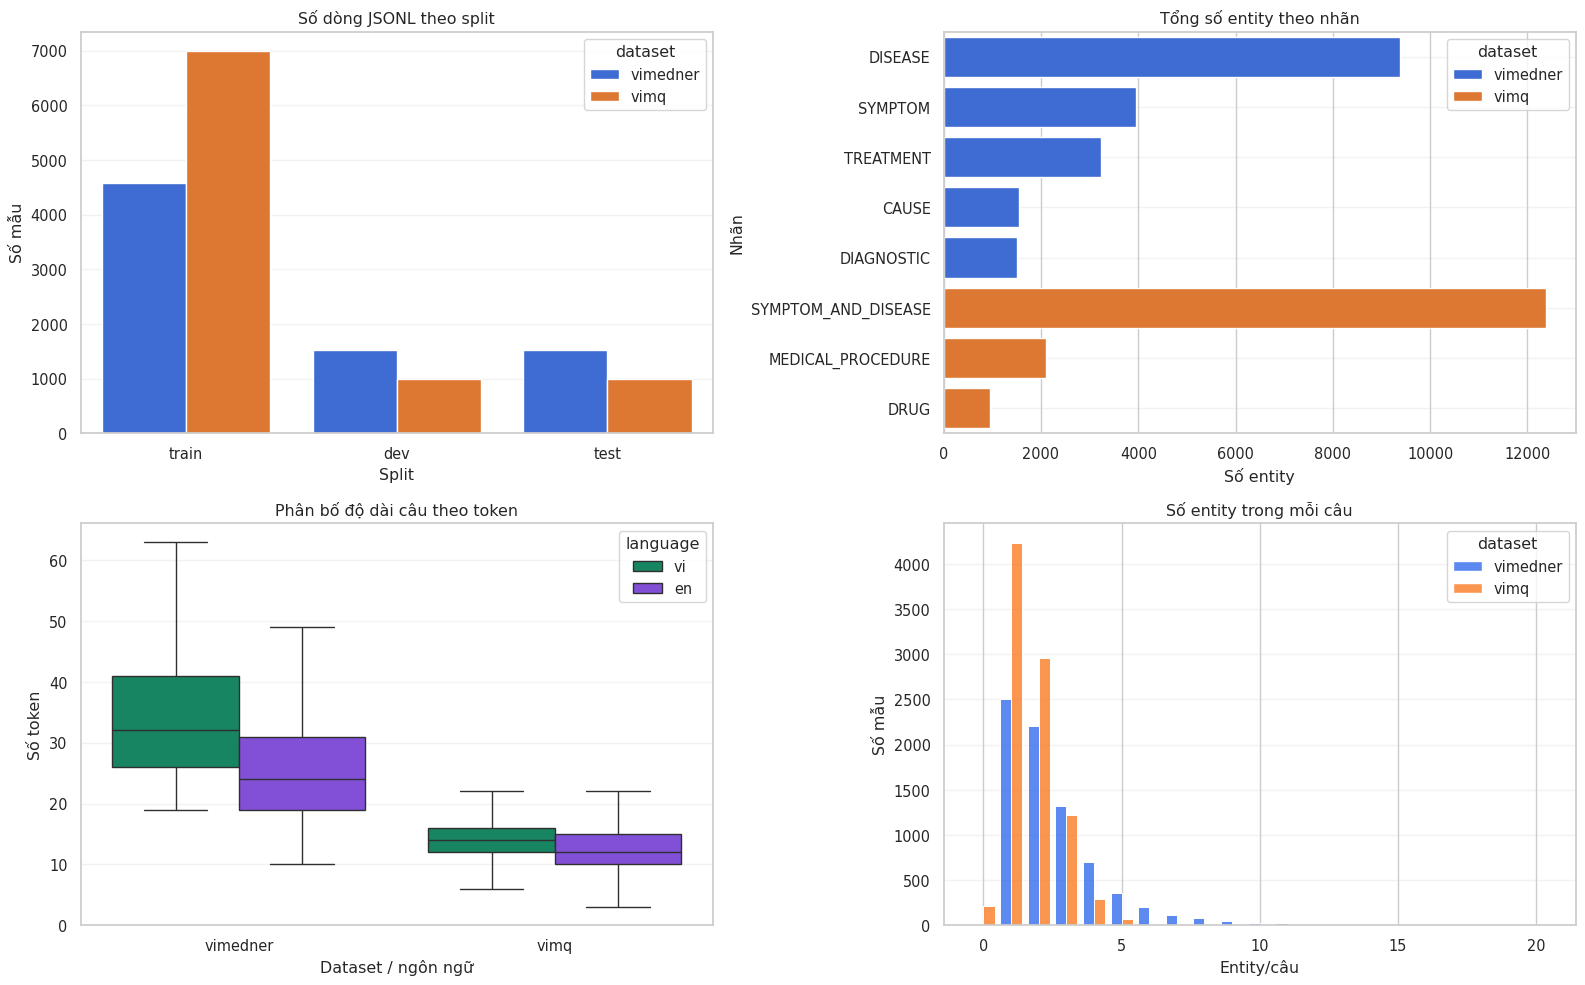

In [ ]:
# Cell mô tả dữ liệu 3: Biểu đồ tổng quan
if HAS_SEABORN:
    sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)
else:
    plt.style.use("ggplot")

dataset_palette = {"vimedner": "#2563eb", "vimq": "#f97316"}
lang_palette = {"vi": "#059669", "en": "#7c3aed"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Số mẫu theo split
if HAS_SEABORN:
    sns.barplot(
        data=summary_df,
        x="split",
        y="samples",
        hue="dataset",
        order=list(SPLITS),
        palette=dataset_palette,
        ax=axes[0, 0],
    )
else:
    summary_df.pivot(index="split", columns="dataset", values="samples").reindex(SPLITS).plot(
        kind="bar",
        ax=axes[0, 0],
    )

axes[0, 0].set_title("Số dòng JSONL theo split")
axes[0, 0].set_xlabel("Split")
axes[0, 0].set_ylabel("Số mẫu")

# 2. Tổng entity theo nhãn
label_total_df = (
    label_df
    .groupby(["dataset", "label"], as_index=False)["count"]
    .sum()
    .sort_values(["dataset", "count"], ascending=[True, False])
)

if HAS_SEABORN:
    sns.barplot(
        data=label_total_df,
        y="label",
        x="count",
        hue="dataset",
        palette=dataset_palette,
        ax=axes[0, 1],
    )
else:
    label_total_df.pivot_table(
        index="label",
        columns="dataset",
        values="count",
        fill_value=0,
    ).plot(kind="barh", ax=axes[0, 1])

axes[0, 1].set_title("Tổng số entity theo nhãn")
axes[0, 1].set_xlabel("Số entity")
axes[0, 1].set_ylabel("Nhãn")

# 3. Độ dài câu
if HAS_SEABORN:
    sns.boxplot(
        data=length_df,
        x="dataset",
        y="tokens",
        hue="language",
        palette=lang_palette,
        showfliers=False,
        ax=axes[1, 0],
    )
else:
    length_df.boxplot(
        column="tokens",
        by=["dataset", "language"],
        showfliers=False,
        ax=axes[1, 0],
    )
    fig.suptitle("")

axes[1, 0].set_title("Phân bố độ dài câu theo token")
axes[1, 0].set_xlabel("Dataset / ngôn ngữ")
axes[1, 0].set_ylabel("Số token")

# 4. Số entity trong mỗi câu
entity_density_df = length_df[length_df["language"] == "vi"].copy()

if HAS_SEABORN:
    sns.histplot(
        data=entity_density_df,
        x="entities",
        hue="dataset",
        multiple="dodge",
        discrete=True,
        shrink=0.8,
        palette=dataset_palette,
        ax=axes[1, 1],
    )
else:
    entity_density_df.groupby(["entities", "dataset"]).size().unstack(fill_value=0).plot(
        kind="bar",
        ax=axes[1, 1],
    )

axes[1, 1].set_title("Số entity trong mỗi câu")
axes[1, 1].set_xlabel("Entity/câu")
axes[1, 1].set_ylabel("Số mẫu")

for ax in axes.flat:
    ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## vimedner: số entity theo nhãn và split

split,train,dev,test
label,,,
DISEASE,"5,611","1,882","1,892"
SYMPTOM,"2,402",804,755
TREATMENT,"1,857",700,673
CAUSE,947,300,309
DIAGNOSTIC,892,291,318


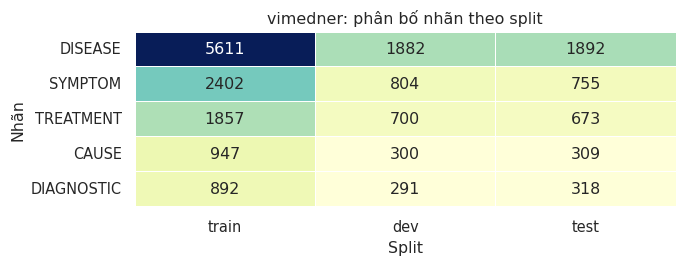

## vimq: số entity theo nhãn và split

split,train,dev,test
label,,,
SYMPTOM_AND_DISEASE,"9,571","1,387","1,419"
MEDICAL_PROCEDURE,"1,623",233,238
DRUG,732,105,119


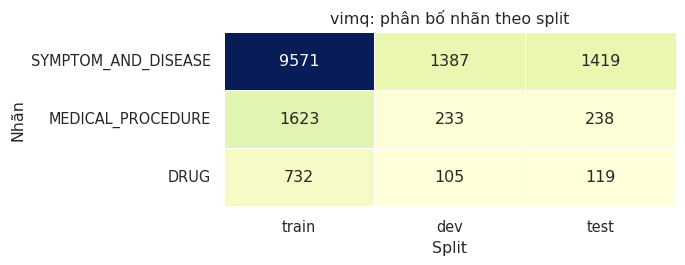

## Top cụm thực thể tiếng Việt thường gặp

,dataset,label,term,freq
805,vimedner,CAUSE,vi khuẩn,139
832,vimedner,CAUSE,virus,62
57,vimedner,CAUSE,chấn thương,55
142,vimedner,CAUSE,cục máu đông,54
248,vimedner,CAUSE,h . pylori,24
256,vimedner,CAUSE,ho,22
519,vimedner,CAUSE,nấm,20
325,vimedner,CAUSE,khối u,14
1299,vimedner,DIAGNOSTIC,nội soi,78
1549,vimedner,DIAGNOSTIC,xét nghiệm máu,68


In [ ]:
# Cell mô tả dữ liệu 4: Heatmap nhãn và top cụm entity
for dataset_name, cfg in DATASETS.items():
    pivot = (
        label_df[label_df["dataset"] == dataset_name]
        .pivot_table(index="label", columns="split", values="count", aggfunc="sum", fill_value=0)
        .reindex(index=list(cfg["labels"]), columns=list(SPLITS), fill_value=0)
    )

    display(Markdown(f"## {dataset_name}: số entity theo nhãn và split"))
    display(pivot.style.background_gradient(cmap="YlGnBu", axis=None).format("{:,.0f}"))

    fig, ax = plt.subplots(figsize=(7, max(2.8, 0.55 * len(pivot))))

    if HAS_SEABORN:
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".0f",
            cmap="YlGnBu",
            cbar=False,
            linewidths=0.5,
            ax=ax,
        )
    else:
        image = ax.imshow(pivot.values, cmap="YlGnBu", aspect="auto")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)

        for y in range(pivot.shape[0]):
            for x in range(pivot.shape[1]):
                ax.text(
                    x,
                    y,
                    f"{pivot.iloc[y, x]:,.0f}",
                    ha="center",
                    va="center",
                    color="black",
                )

        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    ax.set_title(f"{dataset_name}: phân bố nhãn theo split")
    ax.set_xlabel("Split")
    ax.set_ylabel("Nhãn")

    plt.tight_layout()
    plt.show()

display(Markdown("## Top cụm thực thể tiếng Việt thường gặp"))

top_terms = (
    term_df[(term_df["language"] == "vi") & (term_df["term"].str.len() > 0)]
    .groupby(["dataset", "label", "term"], as_index=False)
    .size()
    .rename(columns={"size": "freq"})
    .sort_values(["dataset", "label", "freq", "term"], ascending=[True, True, False, True])
)

top_terms["rank"] = top_terms.groupby(["dataset", "label"])["freq"].rank(
    method="first",
    ascending=False,
)

top_terms = top_terms[top_terms["rank"] <= 8].drop(columns="rank")

display(top_terms.style.format({"freq": "{:,.0f}"}))

## Train NER LoRA on Colab

Notebook này train 2 adapter riêng cho **ViMedNER** và **ViMQ** trên **Tiếng Việt**.

Thiết kế ưu tiên cho Colab ~15GB VRAM:
- base model: **Qwen2.5-3B-Instruct**
- 4-bit quantization
- LoRA fine-tuning
- không cắt thẳng response khi truncation
- lưu adapter + tokenizer + metadata + zip artefacts


In [ ]:
# Cell 0: Install dependencies (Colab)
!pip install -q -U transformers accelerate peft bitsandbytes datasets sentencepiece tiktoken tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.4/684.4 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 113.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is 

In [ ]:
# Cell 1: Imports and config
import os
import json
import gc
import zipfile
import inspect
from dataclasses import dataclass
from pathlib import Path

import torch
from torch.utils.data import Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, Trainer, TrainingArguments
from transformers.utils import logging as hf_logging
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Đã loại bỏ code mount Google Drive

hf_logging.set_verbosity_error()

BASE_MODEL_NAME = 'Qwen/Qwen2.5-3B-Instruct'

# Cập nhật đường dẫn cho môi trường Kaggle
DATA_ROOT = Path('/kaggle/input/datasets/vietnguyencong123/dataset-ppnckh')
WORK_DIR = Path('/kaggle/working')
OUTPUT_ROOT = WORK_DIR / 'ner_adapters'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16,
)

TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
LABELS = {
    'vimedner': ('DISEASE', 'SYMPTOM', 'TREATMENT', 'CAUSE', 'DIAGNOSTIC'),
    'vimq': ('SYMPTOM_AND_DISEASE', 'MEDICAL_PROCEDURE', 'DRUG'),
}

# Cập nhật dict DATASETS để trỏ đúng vào DATA_ROOT mới
DATASETS = {
    'vimedner': {
        'train': DATA_ROOT / 'vimedner' / 'train_fixed_verified.jsonl',
        'dev': DATA_ROOT / 'vimedner' / 'dev_fixed_verified.jsonl'
    },
    'vimq': {
        'train': DATA_ROOT / 'vimq' / 'train_fixed_verified.jsonl',
        'dev': DATA_ROOT / 'vimq' / 'dev_fixed_verified.jsonl'
    },
}

TRAIN_CONFIG = {
    'max_length': 384,
    'epochs': 1.0,
    'batch_size': 1,
    'eval_batch_size': 1,
    'grad_accum': 8,
    'lr': 2e-4,
    'warmup_ratio': 0.03,
    'weight_decay': 0.0,
    'logging_steps': 10,
    'eval_steps': 150,     # Tăng từ 100 lên 150 để tiết kiệm thời gian đánh giá
    'save_steps': 150,     # Lưu đồng bộ với eval_steps để làm checkpoint an toàn
    'save_total_limit': 2,
    'lora_r': 16,
    'lora_alpha': 32,
    'lora_dropout': 0.05,
    'optim': 'paged_adamw_8bit',
}

print('CUDA:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)
print('Data root:', DATA_ROOT)
print('Output root:', OUTPUT_ROOT)

CUDA: True
GPU: Tesla T4
Data root: /kaggle/input/datasets/vietnguyencong123/dataset-ppnckh
Output root: /kaggle/working/ner_adapters


In [ ]:
# Cell 2: Load data
def read_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def normalize_gold_entities(row, allowed_labels=None):
    allowed = set(allowed_labels) if allowed_labels is not None else None
    entities = []
    for e in row.get('entities', []) or []:
        label = e.get('label')
        term = e.get('vi_term')
        start = e.get('vi_start_token_idx')
        end = e.get('vi_end_token_idx')
        if label is None or term is None or start is None or end is None:
            continue
        if allowed is not None and label not in allowed:
            continue
        try:
            start = int(start)
            end = int(end)
        except Exception:
            continue
        term = str(term).strip()
        if not term or start < 0 or end < start:
            continue
        entities.append({'label': label, 'term': term, 'start_token_idx': start, 'end_token_idx': end})
    entities.sort(key=lambda x: (x['start_token_idx'], x['end_token_idx'], x['label'], x['term']))
    return entities

# Cập nhật lại tên file cho khớp chính xác với cấu trúc thư mục trên Kaggle
DATASETS = {
    'vimedner': {
        'train': DATA_ROOT / 'vimedner' / 'train_fixed_verified.jsonl',
        'dev': DATA_ROOT / 'vimedner' / 'dev_fixed_verified.jsonl',
        'test': DATA_ROOT / 'vimedner' / 'test_fixed_verified.jsonl',
    },
    'vimq': {
        'train': DATA_ROOT / 'vimq' / 'train_fixed_verified.jsonl',
        'dev': DATA_ROOT / 'vimq' / 'dev_fixed_verified.jsonl',
        'test': DATA_ROOT / 'vimq' / 'test_fixed_verified.jsonl',
    },
}

for name, cfg in DATASETS.items():
    for split in ('train', 'dev', 'test'):
        if not cfg[split].exists():
            raise FileNotFoundError(f'Missing {name}/{split}: {cfg[split]}')
    print(name, 'train=', cfg['train'], 'dev=', cfg['dev'], 'test=', cfg['test'])
    rows = read_jsonl(cfg['train'])[:2]
    for row in rows:
        print('vi:', row.get('vi_sentence_str', '')[:120])
        print('gold:', normalize_gold_entities(row, LABELS[name])[:3])

vimedner train= /kaggle/input/datasets/vietnguyencong123/dataset-ppnckh/vimedner/train_fixed_verified.jsonl dev= /kaggle/input/datasets/vietnguyencong123/dataset-ppnckh/vimedner/dev_fixed_verified.jsonl test= /kaggle/input/datasets/vietnguyencong123/dataset-ppnckh/vimedner/test_fixed_verified.jsonl
vi: các khối u não xảy ra thường xuyên hơn ở người da trắng hơn là ở người của các chủng tộc khác .
gold: [{'label': 'DISEASE', 'term': 'khối u não', 'start_token_idx': 1, 'end_token_idx': 3}]
vi: biến chứng có thể gặp khi mắc sởi nếu không được phát hiện và can thiệp kịp thời , có thể gây ra các biến chứng nguy hiể
gold: [{'label': 'DISEASE', 'term': 'sởi', 'start_token_idx': 7, 'end_token_idx': 7}, {'label': 'DISEASE', 'term': 'bệnh sởi', 'start_token_idx': 41, 'end_token_idx': 42}]
vimq train= /kaggle/input/datasets/vietnguyencong123/dataset-ppnckh/vimq/train_fixed_verified.jsonl dev= /kaggle/input/datasets/vietnguyencong123/dataset-ppnckh/vimq/dev_fixed_verified.jsonl test= /kaggle/input

In [ ]:
# Cell 3: Prompt and response formatting
import json

def build_system_prompt(dataset_name, labels):
    return f'''Bạn là hệ thống nhận dạng và trích xuất thực thể y tế (NER).
Dataset/schema: {dataset_name}
Ngôn ngữ đầu vào: tiếng Việt

Chỉ được dùng đúng các nhãn sau:
{', '.join(labels)}

Quy tắc bắt buộc:
1) Trả về DUY NHẤT 1 JSON object hợp lệ, không dùng markdown code block (không bao bọc bởi ```json), không giải thích gì thêm.
2) JSON phải có đúng key "entities".
3) Mỗi entity gồm đúng 4 key: text, label, start, end.
4) start/end là chỉ số token (tính theo việc tách câu bằng khoảng trắng).
5) end là vị trí kết thúc INCLUSIVE.
6) Nếu không có thực thể, trả về: {{"entities":[]}}'''

def build_messages(dataset_name, labels, text):
    return [
        {'role': 'system', 'content': build_system_prompt(dataset_name, labels)},
        # Tối ưu: truyền thẳng text, để Chat Template tự lo việc format tags user/assistant
        {'role': 'user', 'content': f'{text}'},
    ]

def format_response(entities):
    payload = {'entities': [{'text': e['term'], 'label': e['label'], 'start': e['start_token_idx'], 'end': e['end_token_idx']} for e in entities]}
    # Tối ưu: Thêm separators=(',', ':') để loại bỏ khoảng trắng thừa, giúp nén output và tiết kiệm token
    return json.dumps(payload, ensure_ascii=False, separators=(',', ':'))

def build_sft_records(rows, dataset_name, labels):
    records = []
    for idx, row in enumerate(rows):
        text = row.get('vi_sentence_str')
        if not text:
            continue
        entities = normalize_gold_entities(row, labels)
        records.append({
            'id': f'{dataset_name}-{idx}-vi',
            'dataset': dataset_name,
            'language': 'vi',
            'text': text,
            'prompt': build_messages(dataset_name, labels, text),
            'response': format_response(entities),
            'entities': entities
        })
    return records

for name in DATASETS:
    recs = build_sft_records(read_jsonl(DATASETS[name]['train'])[:2], name, LABELS[name])
    print(name, 'records=', len(recs))
    if recs:
        print(recs[0]['response'])

vimedner records= 2
{"entities":[{"text":"khối u não","label":"DISEASE","start":1,"end":3}]}
vimq records= 2
{"entities":[{"text":"Hẹp động mạch thận","label":"SYMPTOM_AND_DISEASE","start":0,"end":3},{"text":"hiến thận","label":"MEDICAL_PROCEDURE","start":8,"end":9}]}


In [ ]:
# Cell 4: Tokenizer and safe dataset

def load_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    # Right padding là chuẩn xác nhất cho quá trình Training
    tokenizer.padding_side = 'right'
    return tokenizer

class NerSftDataset(Dataset):
    def __init__(self, records, tokenizer, max_length):
        self.records = records
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.records)

    def _to_ids(self, value):
        if hasattr(value, 'input_ids'):
            return value.input_ids
        return value

    def __getitem__(self, index):
        record = self.records[index]

        # record['prompt'] là list of dicts từ Cell 3.
        # apply_chat_template tự động chèn các token hệ thống (<|im_start|>, <|im_end|>)
        prompt_ids = self._to_ids(self.tokenizer.apply_chat_template(
            record['prompt'],
            tokenize=True,
            add_generation_prompt=True
        ))

        response_ids = self.tokenizer(record['response'], add_special_tokens=False).input_ids

        if self.tokenizer.eos_token_id is not None:
            response_ids = response_ids + [self.tokenizer.eos_token_id]

        total_len = len(prompt_ids) + len(response_ids)

        # TỐI ƯU TRỌNG TÂM: Bỏ qua (skip) các mẫu vượt giới hạn max_length
        # Thay vì cắt gọt làm mất System Prompt chứa quy tắc xuất JSON
        if total_len > self.max_length:
            return None

        input_ids = prompt_ids + response_ids
        # Đánh dấu phần prompt là -100 để không tính loss vào phần câu hỏi
        labels = [-100] * len(prompt_ids) + response_ids

        return {
            'input_ids': input_ids,
            'attention_mask': [1] * len(input_ids),
            'labels': labels
        }

@dataclass
class NerDataCollator:
    tokenizer: object

    def __call__(self, features):
        # Lọc sạch các mẫu None bị loại từ quá trình kiểm tra chiều dài ở Dataset
        features = [f for f in features if f is not None]

        if not features:
            return {} # Fallback an toàn nếu batch trống

        max_len = max(len(x['input_ids']) for x in features)
        input_ids, attention_mask, labels = [], [], []

        for item in features:
            pad_len = max_len - len(item['input_ids'])
            # Padding bên phải
            input_ids.append(item['input_ids'] + [self.tokenizer.pad_token_id] * pad_len)
            attention_mask.append(item['attention_mask'] + [0] * pad_len)
            labels.append(item['labels'] + [-100] * pad_len)

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.long)
        }

tokenizer = load_tokenizer()
print('pad_token_id=', tokenizer.pad_token_id)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

pad_token_id= 151643


In [ ]:
# Cell 5: Training helpers
def build_training_args(output_dir):
    # Hàm này dùng dự phòng nếu bạn muốn chuyển sang dùng Hugging Face Trainer
    params = dict(output_dir=str(output_dir), num_train_epochs=TRAIN_CONFIG['epochs'], per_device_train_batch_size=TRAIN_CONFIG['batch_size'], per_device_eval_batch_size=TRAIN_CONFIG['eval_batch_size'], gradient_accumulation_steps=TRAIN_CONFIG['grad_accum'], learning_rate=TRAIN_CONFIG['lr'], warmup_ratio=TRAIN_CONFIG['warmup_ratio'], weight_decay=TRAIN_CONFIG['weight_decay'], logging_steps=TRAIN_CONFIG['logging_steps'], save_steps=TRAIN_CONFIG['save_steps'], eval_steps=TRAIN_CONFIG['eval_steps'], save_total_limit=TRAIN_CONFIG['save_total_limit'], optim=TRAIN_CONFIG['optim'], report_to='none', remove_unused_columns=False, gradient_checkpointing=True, fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(), bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported())
    sig = inspect.signature(TrainingArguments.__init__)
    if 'eval_strategy' in sig.parameters:
        params['eval_strategy'] = 'steps'
    else:
        params['evaluation_strategy'] = 'steps'
    if 'save_strategy' in sig.parameters:
        params['save_strategy'] = 'steps'
    if 'logging_strategy' in sig.parameters:
        params['logging_strategy'] = 'steps'
    return TrainingArguments(**params)

def load_base_model():
    model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME, quantization_config=bnb_config, device_map='auto', trust_remote_code=True)
    model.config.use_cache = False

    # TỐI ƯU VRAM: Ép mô hình bật gradient checkpointing cho custom training loop
    model.gradient_checkpointing_enable()

    model = prepare_model_for_kbit_training(model)
    return model

def make_lora_model():
    base = load_base_model()
    lora_config = LoraConfig(r=TRAIN_CONFIG['lora_r'], lora_alpha=TRAIN_CONFIG['lora_alpha'], lora_dropout=TRAIN_CONFIG['lora_dropout'], bias='none', task_type='CAUSAL_LM', target_modules=TARGET_MODULES)
    model = get_peft_model(base, lora_config)
    model.print_trainable_parameters()
    return model

In [ ]:
# Cell 6: Build train/eval records
def load_records_for_dataset(dataset_name):
    train_rows = read_jsonl(DATASETS[dataset_name]['train'])
    dev_rows = read_jsonl(DATASETS[dataset_name]['dev'])
    return build_sft_records(train_rows, dataset_name, LABELS[dataset_name]), build_sft_records(dev_rows, dataset_name, LABELS[dataset_name])

all_data = {}
for name in DATASETS:
    train_records, dev_records = load_records_for_dataset(name)
    all_data[name] = {'train': train_records, 'dev': dev_records}
    print(name, 'train=', len(train_records), 'dev=', len(dev_records))
    if train_records:
        print('first response:', train_records[0]['response'])

vimedner train= 4576 dev= 1524
first response: {"entities":[{"text":"khối u não","label":"DISEASE","start":1,"end":3}]}
vimq train= 7000 dev= 1000
first response: {"entities":[{"text":"Hẹp động mạch thận","label":"SYMPTOM_AND_DISEASE","start":0,"end":3},{"text":"hiến thận","label":"MEDICAL_PROCEDURE","start":8,"end":9}]}


In [ ]:
# Cell 7: Train one adapter (Sử dụng Hugging Face Trainer)

import gc
import torch
import json
from transformers import Trainer
from transformers.trainer_utils import get_last_checkpoint

def train_one_adapter(dataset_name):
    output_dir = OUTPUT_ROOT / f'qwen2p5_3b_{dataset_name}_ner_lora'
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f'[{dataset_name}] 1/5 Loading model...')
    model = make_lora_model()

    print(f'[{dataset_name}] 2/5 Building datasets...')
    # Sử dụng NerSftDataset và NerDataCollator đã định nghĩa ở Cell 4
    train_dataset = [x for x in NerSftDataset(all_data[dataset_name]['train'], tokenizer, TRAIN_CONFIG['max_length']) if x is not None]
    eval_dataset = [x for x in NerSftDataset(all_data[dataset_name]['dev'], tokenizer, TRAIN_CONFIG['max_length']) if x is not None]
    print(f'[{dataset_name}] usable train={len(train_dataset)} usable dev={len(eval_dataset)}')

    print(f'[{dataset_name}] 3/5 Preparing Trainer...')
    training_args = build_training_args(output_dir)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=NerDataCollator(tokenizer),
    )

    print(f'[{dataset_name}] 4/5 Training...')
    # TỰ ĐỘNG RESUME: Tìm xem có checkpoint nào train dở không (do bị ngắt Kaggle)
    last_checkpoint = get_last_checkpoint(output_dir)
    if last_checkpoint:
        print(f"[{dataset_name}] Found checkpoint: {last_checkpoint}. Resuming training...")

    # Lệnh này sẽ tự động lo vòng lặp train, tính loss, cập nhật gradient và lưu file
    trainer.train(resume_from_checkpoint=last_checkpoint)

    print(f'[{dataset_name}] 5/5 Saving final model & metadata...')
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    # Metadata được cập nhật đồng bộ với format_response ở Cell 3
    metadata = {
        'base_model': BASE_MODEL_NAME,
        'dataset': dataset_name,
        'labels': list(LABELS[dataset_name]),
        'language': 'vi',
        'max_length': TRAIN_CONFIG['max_length'],
        'format': {
            'response': {
                'entities': [
                    {'label': 'LABEL', 'text': 'text', 'start': 0, 'end': 0}
                ]
            }
        },
    }
    with open(output_dir / 'ner_adapter_metadata.json', 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    # TỐI ƯU VRAM: Ép xóa sạch model và dọn rác GPU để dành chỗ cho adapter tiếp theo
    del model
    del trainer
    gc.collect()
    torch.cuda.empty_cache()

    print(f'[{dataset_name}] Done. Saved to: {output_dir}')
    return output_dir

In [ ]:
# Cell 8: Run training for ViMedNER only
# vimedner_out = train_one_adapter('vimedner')
# print('ViMedNER adapter:', vimedner_out)

In [ ]:
# Cell 8.5: Copy checkpoint và Resume training cho ViMQ
import shutil
import os
from pathlib import Path

print("--- CHUẨN BỊ MÔI TRƯỜNG RESUME ---")

# 1. Đường dẫn checkpoint từ Dataset bạn đã upload
# Lưu ý: Tên thư mục ở sidebar Kaggle là vimq_continue (dùng dấu gạch dưới)
input_checkpoint_dir = Path('/kaggle/input/datasets/vietnguyencong123/vimq-continue/qwen2p5_3b_vimq_ner_lora/checkpoint-600')

# 2. Đường dẫn đích trong thư mục /kaggle/working
output_dir = OUTPUT_ROOT / 'qwen2p5_3b_vimq_ner_lora'
working_checkpoint_dir = output_dir / 'checkpoint-600'

# 3. Tiến hành copy dữ liệu sang working
if input_checkpoint_dir.exists():
    if not working_checkpoint_dir.exists():
        print(f"Đang copy checkpoint từ Input sang Working...")
        print(f"Từ: {input_checkpoint_dir}")
        print(f"Đến: {working_checkpoint_dir}")

        # Copy toàn bộ thư mục
        shutil.copytree(input_checkpoint_dir, working_checkpoint_dir)
        print("✅ Copy hoàn tất!")
    else:
        print("✅ Checkpoint-600 đã tồn tại trong working, không cần copy lại.")
else:
    print(f"❌ CẢNH BÁO: Không tìm thấy dữ liệu tại {input_checkpoint_dir}.")
    print("Vui lòng kiểm tra lại chính xác đường dẫn (/kaggle/input/...)")

# 4. Kích hoạt huấn luyện tiếp ViMQ
print("\n--- BẮT ĐẦU RESUME HUẤN LUYỆN VIMQ ---")
vimq_out = train_one_adapter('vimq')
print('🎉 ViMQ adapter đã hoàn thành và lưu tại:', vimq_out)

--- CHUẨN BỊ MÔI TRƯỜNG RESUME ---
Đang copy checkpoint từ Input sang Working...
Từ: /kaggle/input/datasets/vietnguyencong123/vimq-continue/qwen2p5_3b_vimq_ner_lora/checkpoint-600
Đến: /kaggle/working/ner_adapters/qwen2p5_3b_vimq_ner_lora/checkpoint-600
✅ Copy hoàn tất!

--- BẮT ĐẦU RESUME HUẤN LUYỆN VIMQ ---
[vimq] 1/5 Loading model...


model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607
[vimq] 2/5 Building datasets...
[vimq] usable train=6994 usable dev=999
[vimq] 3/5 Preparing Trainer...
[vimq] 4/5 Training...
[vimq] Found checkpoint: /kaggle/working/ner_adapters/qwen2p5_3b_vimq_ner_lora/checkpoint-600. Resuming training...
{'loss': '0.04041', 'grad_norm': '0.8393', 'learning_rate': '6.274e-05', 'epoch': '0.6977'}
{'loss': '0.05952', 'grad_norm': '0.8103', 'learning_rate': '6.038e-05', 'epoch': '0.7092'}
{'loss': '0.04318', 'grad_norm': '0.4067', 'learning_rate': '5.802e-05', 'epoch': '0.7206'}
{'loss': '0.04742', 'grad_norm': '0.357', 'learning_rate': '5.566e-05', 'epoch': '0.7321'}
{'loss': '0.05027', 'grad_norm': '0.5526', 'learning_rate': '5.33e-05', 'epoch': '0.7435'}
{'loss': '0.04616', 'grad_norm': '0.3031', 'learning_rate': '5.094e-05', 'epoch': '0.7549'}
{'loss': '0.03492', 'grad_norm': '0.2436', 'learning_rate': '4.858e-05', 'epoch': '0.7664'}
{'loss': '0.04831', 'grad_norm': '0

In [ ]:
# Cell 9: Run training for ViMQ only
# vimq_out = train_one_adapter('vimq')
# print('ViMQ adapter:', vimq_out)

In [ ]:
# Cell 10: Zip artefacts for download
def zip_directory(src_dir, zip_path):
    # Lệnh này đảm bảo thư mục /kaggle/working được tạo ra trước khi nén file
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for path in sorted(Path(src_dir).rglob('*')):
            if path.is_file():
                zf.write(path, arcname=path.relative_to(src_dir))

zip_path = WORK_DIR / 'ner_adapters.zip'
zip_directory(OUTPUT_ROOT, zip_path)
print('zip:', zip_path)
print('size_mb:', round(zip_path.stat().st_size / 1024 / 1024, 2))

zip: /kaggle/working/ner_adapters.zip
size_mb: 426.59


#Colab

In [ ]:
# Cell 1: Kết nối với Google Drive
from google.colab import drive

print("Đang tiến hành kết nối với Google Drive...")
# Lệnh này sẽ yêu cầu bạn cấp quyền truy cập Drive bằng một popup xác nhận
drive.mount('/content/drive')
print("✅ Kết nối Google Drive thành công!")

Đang tiến hành kết nối với Google Drive...
Mounted at /content/drive
✅ Kết nối Google Drive thành công!


In [ ]:
# Cell 2: Kiểm tra thư mục model adapter trên Google Drive
import os
from pathlib import Path

# Đường dẫn trỏ thẳng vào thư mục mô hình trên Drive của bạn
adapter_path = Path("/content/drive/MyDrive/ppnckh/qwen2p5_3b_vimedner_ner_lora")

print("🔍 Đang tiến hành quét thư mục mô hình trên Google Drive...")
if adapter_path.exists():
    print(f"✅ Tìm thấy thư mục mô hình tại: {adapter_path}")
    print("\nDanh sách các file hiện có trong thư mục:")

    # Liệt kê các file để kiểm tra dung lượng trực tiếp trên Drive
    for f in adapter_path.iterdir():
        if f.is_file():
            print(f"  - {f.name} ({f.stat().st_size / 1024 / 1024:.2f} MB)")
        else:
            print(f"  - [{f.name}/]")

    # Kiểm tra sự tồn tại của file trọng số cốt lõi
    if (adapter_path / "adapter_model.safetensors").exists():
        print("\n🎉 Cấu trúc chính xác! File 'adapter_model.safetensors' đã sẵn sàng để nạp.")
    else:
        print("\n❌ CẢNH BÁO: Thiếu file 'adapter_model.safetensors'. Bạn hãy kiểm tra lại trên Drive.")
else:
    print(f"❌ Không tìm thấy thư mục mô hình tại: {adapter_path}")
    print("Vui lòng kiểm tra lại xem tên thư mục hoặc đường dẫn ppnckh trên Drive đã đúng chuẩn chưa.")

🔍 Đang tiến hành quét thư mục mô hình trên Google Drive...
✅ Tìm thấy thư mục mô hình tại: /content/drive/MyDrive/ppnckh/qwen2p5_3b_vimedner_ner_lora

Danh sách các file hiện có trong thư mục:
  - adapter_config.json (0.00 MB)
  - chat_template.jinja (0.00 MB)
  - adapter_model.safetensors (114.25 MB)
  - [checkpoint-450/]
  - README.md (0.00 MB)
  - [checkpoint-530/]
  - tokenizer_config.json (0.00 MB)
  - ner_adapter_metadata.json (0.00 MB)
  - training_args.bin (0.00 MB)
  - tokenizer.json (10.89 MB)

🎉 Cấu trúc chính xác! File 'adapter_model.safetensors' đã sẵn sàng để nạp.


In [ ]:
# Cell 3: Tải Base Model và nạp trực tiếp Adapter từ Google Drive
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from google.colab import drive

# 0. Kết nối Google Drive (Bước quan trọng nhất)
print("0. Đang kết nối với Google Drive...")
# Lệnh này sẽ hiện ra một popup nhỏ, bạn bấm "Kết nối với Google Drive" và Cho phép nhé
drive.mount('/content/drive')

base_model_id = "Qwen/Qwen2.5-3B-Instruct"

# 1. Đường dẫn trỏ thẳng vào thư mục model trên Drive của bạn
adapter_path = "/content/drive/MyDrive/ppnckh/qwen2p5_3b_vimedner_ner_lora"

print("\n1. Đang tải Tokenizer và Base Model từ Hugging Face Hub...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("\n2. Đang nạp LoRA Adapter từ Google Drive vào bộ nhớ...")
try:
    model = PeftModel.from_pretrained(base_model, adapter_path)
    print("✅ Hệ thống ViMedNER đã sẵn sàng chạy dự đoán dữ liệu!")
except Exception as e:
    print(f"❌ Lỗi: {e}\n(Hãy kiểm tra lại xem tên thư mục trong đường dẫn đã đúng 100% chưa nhé)")

0. Đang kết nối với Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

1. Đang tải Tokenizer và Base Model từ Hugging Face Hub...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]


2. Đang nạp LoRA Adapter từ Google Drive vào bộ nhớ...
✅ Hệ thống ViMedNER đã sẵn sàng chạy dự đoán dữ liệu!


## Gen Vimedner


In [ ]:
# Cell 4 (Cập nhật): Chạy Inference hàng loạt trên TOÀN BỘ dữ liệu Test
import json
import torch
from tqdm.auto import tqdm # Thư viện tạo thanh tiến trình cho đẹp

# 1. Khai báo đường dẫn file
input_file_path = "/content/drive/MyDrive/ppnckh/vimedner/test_fixed_verified.jsonl"
# Đổi tên file output để lưu bản full
output_file_path = "/content/drive/MyDrive/ppnckh/vimedner_test_results_full.jsonl"

# Hàm build prompt (Giữ nguyên cấu trúc đã học)
def build_prompt(text):
    system_prompt = '''Bạn là hệ thống nhận dạng và trích xuất thực thể y tế (NER).
Dataset/schema: vimedner
Ngôn ngữ đầu vào: tiếng Việt

Chỉ được dùng đúng các nhãn sau:
DISEASE, SYMPTOM, TREATMENT, CAUSE, DIAGNOSTIC

Quy tắc bắt buộc:
1) Trả về DUY NHẤT 1 JSON object hợp lệ, không dùng markdown code block (không bao bọc bởi ```json), không giải thích gì thêm.
2) JSON phải có đúng key "entities".
3) Mỗi entity gồm đúng 4 key: text, label, start, end.
4) start/end là chỉ số token (tính theo việc tách câu bằng khoảng trắng).
5) end là vị trí kết thúc INCLUSIVE.
6) Nếu không có thực thể, trả về: {"entities":[]}'''

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": text}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# 2. Đọc TOÀN BỘ dữ liệu từ file dataset
test_sentences = []
try:
    with open(input_file_path, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            # ĐÃ XÓA LỆNH GIỚI HẠN 100 CÂU Ở ĐÂY
            line = line.strip()
            if line:
                data = json.loads(line)
                # Đảm bảo key chứa text tiếng Việt của bạn là 'vi_sentence_str'
                text = data.get('vi_sentence_str', '')
                if text:
                    test_sentences.append(text)
    print(f"✅ Đã tải thành công {len(test_sentences)} câu để test full.")
except Exception as e:
    print(f"❌ Lỗi khi đọc file: {e}")

# 3. Chạy inference và lưu kết quả
print(f"🚀 Bắt đầu trích xuất thực thể...")

results = []
# Mở file ghi (chế độ 'w')
with open(output_file_path, 'w', encoding='utf-8') as f_out:
    for text in tqdm(test_sentences, desc="Processing"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=256,
                pad_token_id=tokenizer.eos_token_id,
                do_sample=False # Xóa temperature để tránh báo warning đỏ
            )

        input_length = inputs.input_ids.shape[1]
        response = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)

        # Lưu vào dict để xuất file
        result_obj = {
            "input_text": text,
            "predicted_json": response
        }

        # Ghi từng dòng ra file ngay lập tức (phòng hờ Colab crash)
        f_out.write(json.dumps(result_obj, ensure_ascii=False) + '\n')
        results.append(result_obj)

print(f"\n✅ Hoàn tất! Kết quả full đã được lưu tại: {output_file_path}")

# In thử 2 kết quả đầu tiên xem cho vui
print("\n--- SAMPLE KẾT QUẢ ---")
for i in range(min(2, len(results))):
    print(f"Câu {i+1}: {results[i]['input_text']}")
    print(f"AI Trích xuất: {results[i]['predicted_json']}\n")

✅ Đã tải thành công 1525 câu để test full.
🚀 Bắt đầu trích xuất thực thể...


Processing:   0%|          | 0/1525 [00:00<?, ?it/s]


✅ Hoàn tất! Kết quả full đã được lưu tại: /content/drive/MyDrive/ppnckh/vimedner_test_results_full.jsonl

--- SAMPLE KẾT QUẢ ---
Câu 1: dạng phối hợp : những người mắc loại bệnh phong này có các triệu chứng của cả hai dạng bệnh lao và bệnh lepromatous .
AI Trích xuất: {"entities":[{"text":"bệnh phong","label":"DISEASE","start":8,"end":9},{"text":"bệnh lao","label":"DISEASE","start":17,"end":18},{"text":"bệnh lepromatous","label":"DISEASE","start":20,"end":21}]}

Câu 2: viêm màng não do virus : biến chứng hiếm gặp , xảy ra khi virus xâm nhập vào hệ thống thần kinh trung ương của cơ thể ( não và tủy sống ) .
AI Trích xuất: {"entities":[{"text":"viêm màng não","label":"DISEASE","start":0,"end":2},{"text":"virus","label":"CAUSE","start":5,"end":5}]}



In [ ]:
# Cell 5: Tối ưu Hậu xử lý (Lọc Ảo giác + Cắt Dấu câu) & Đánh giá (Exact & Khớp IoU >= 50%)
import json
import string

true_file_path = "/content/drive/MyDrive/ppnckh/vimedner/test_fixed_verified.jsonl"
pred_file_path = "/content/drive/MyDrive/ppnckh/vimedner_test_results.jsonl"
output_super_cleaned_path = "/content/drive/MyDrive/ppnckh/vimedner_super_cleaned.jsonl"

print("🚀 Đang tiến hành Hậu xử lý và Đánh giá toàn diện (Tích hợp phạt IoU)...")

# Tập hợp dấu câu cần gọt bỏ
VI_PUNCT = string.punctuation + "”“\"'…"

def find_real_token_indices(sentence, term):
    """Tìm Index thực tế của cụm từ sau khi gọt rửa."""
    if not term or not sentence: return None, None
    s_tokens = sentence.split()
    # Cắt dấu câu ở 2 đầu của term do AI sinh ra
    term_cleaned = term.strip(VI_PUNCT + " ")
    if not term_cleaned: return None, None

    t_tokens = term_cleaned.split()
    n_s, n_t = len(s_tokens), len(t_tokens)

    s_tokens_lower = [t.lower() for t in s_tokens]
    t_tokens_lower = [t.lower() for t in t_tokens]

    for i in range(n_s - n_t + 1):
        if s_tokens_lower[i:i+n_t] == t_tokens_lower:
            return i, i + n_t - 1, term_cleaned

    return None, None, None

def calculate_iou(p_start, p_end, g_start, g_end):
    """Tính tỷ lệ IoU (Intersection over Union) giữa 2 khoảng Index"""
    intersection_start = max(p_start, g_start)
    intersection_end = min(p_end, g_end)

    # Nếu không giao nhau
    if intersection_start > intersection_end:
        return 0.0

    intersection_length = intersection_end - intersection_start + 1
    p_length = p_end - p_start + 1
    g_length = g_end - g_start + 1
    union_length = p_length + g_length - intersection_length

    return intersection_length / union_length

# 1. Đọc dữ liệu
predictions = []
with open(pred_file_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip(): predictions.append(json.loads(line.strip()))

trues = []
with open(true_file_path, 'r', encoding='utf-8') as f:
    for idx, line in enumerate(f):
        if idx >= len(predictions): break
        if line.strip(): trues.append(json.loads(line.strip()))

# Biến lưu trữ điểm Exact Match (Strict)
em_tp, em_fp, em_fn = 0, 0, 0
# Biến lưu trữ điểm Partial Match (IoU Relaxed)
pm_tp, pm_fp, pm_fn = 0, 0, 0

# NGƯỠNG PHẠT IOU (50% trùng khớp mới tính là đúng)
IOU_THRESHOLD = 0.5

with open(output_super_cleaned_path, 'w', encoding='utf-8') as f_out:
    for i in range(len(predictions)):
        vi_sentence = trues[i].get('vi_sentence_str', '')

        # --- CHUẨN BỊ GOLD ---
        gold_list = []
        gold_exact_set = set()
        gold_partial_list = [] # Lưu (label, start, end)

        for e in trues[i].get('entities', []):
            term = str(e.get("vi_term")).strip()
            label = str(e.get("label")).strip()
            start = int(e.get("vi_start_token_idx", -1))
            end = int(e.get("vi_end_token_idx", -1))

            gold_list.append({"label": label, "vi_term": term, "start": start, "end": end})
            gold_exact_set.add((term.lower(), label, start, end))
            gold_partial_list.append((label, start, end))

        # --- XỬ LÝ PRED ---
        pred_list = []
        pred_exact_set = set()
        pred_partial_list = []

        try:
            pred_data = json.loads(predictions[i]['predicted_json'])
            for e in pred_data.get('entities', []):
                raw_term = str(e.get("text", ""))
                label = str(e.get("label", "")).strip()

                # Gọi hàm làm sạch và tìm index
                real_start, real_end, cleaned_term = find_real_token_indices(vi_sentence, raw_term)

                # CHỈ LẤY NHỮNG THỰC THỂ TÌM THẤY INDEX (Lọc ảo giác)
                if real_start is not None and real_end is not None:
                    pred_list.append({"label": label, "vi_term": cleaned_term, "start": real_start, "end": real_end})
                    pred_exact_set.add((cleaned_term.lower(), label, real_start, real_end))
                    pred_partial_list.append((label, real_start, real_end))
        except:
            pass # AI sinh lỗi JSON

        f_out.write(json.dumps({"vi_sentence": vi_sentence, "gold": gold_list, "pred": pred_list}, ensure_ascii=False) + '\n')

        # --- CHẤM ĐIỂM EXACT MATCH ---
        em_tp += len(gold_exact_set.intersection(pred_exact_set))
        em_fp += len(pred_exact_set - gold_exact_set)
        em_fn += len(gold_exact_set - pred_exact_set)

        # --- CHẤM ĐIỂM PARTIAL MATCH (Khớp IoU >= 50%) ---
        matched_gold_indices = set()
        matched_pred_indices = set()

        for p_idx, (p_label, p_start, p_end) in enumerate(pred_partial_list):
            for g_idx, (g_label, g_start, g_end) in enumerate(gold_partial_list):
                if p_label == g_label:
                    # Tính độ đo IoU
                    iou = calculate_iou(p_start, p_end, g_start, g_end)

                    # CHỈ CỘNG ĐIỂM NẾU ĐỘ TRÙNG KHỚP >= 50% (Tránh AI đoán mò lan man)
                    if iou >= IOU_THRESHOLD:
                        matched_pred_indices.add(p_idx)
                        matched_gold_indices.add(g_idx)

        pm_tp += len(matched_pred_indices)
        pm_fp += len(pred_partial_list) - len(matched_pred_indices)
        pm_fn += len(gold_partial_list) - len(matched_gold_indices)

# --- TÍNH TOÁN VÀ IN BÁO CÁO ---
def calculate_metrics(tp, fp, fn):
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    return p, r, f1

em_p, em_r, em_f1 = calculate_metrics(em_tp, em_fp, em_fn)
pm_p, pm_r, pm_f1 = calculate_metrics(pm_tp, pm_fp, pm_fn)

print("\n" + "="*65)
print(" 🏆 BÁO CÁO KẾT QUẢ NER TOÀN DIỆN (ĐÃ TÍCH HỢP PHẠT IoU)")
print("="*65)
print("1. STRICT EVALUATION (Exact Match - Khớp 100%)")
print(f"   - True Positives : {em_tp}")
print(f"   - False Positives: {em_fp}")
print(f"   - False Negatives: {em_fn}")
print(f"   👉 Precision: {em_p*100:.2f}% | Recall: {em_r*100:.2f}% | F1-Score: {em_f1*100:.2f}%")
print("-" * 65)
print(f"2. RELAXED EVALUATION (Partial Match - Khớp IoU >= {IOU_THRESHOLD*100:.0f}%)")
print("   (Loại bỏ những trường hợp AI đoán quá dài hoặc quá ngắn)")
print(f"   - True Positives : {pm_tp}")
print(f"   - False Positives: {pm_fp}")
print(f"   - False Negatives: {pm_fn}")
print(f"   👉 Precision: {pm_p*100:.2f}% | Recall: {pm_r*100:.2f}% | F1-Score: {pm_f1*100:.2f}%")
print("="*65)

🚀 Đang tiến hành Hậu xử lý và Đánh giá toàn diện (Tích hợp phạt IoU)...

 🏆 BÁO CÁO KẾT QUẢ NER TOÀN DIỆN (ĐÃ TÍCH HỢP PHẠT IoU)
1. STRICT EVALUATION (Exact Match - Khớp 100%)
   - True Positives : 159
   - False Positives: 67
   - False Negatives: 96
   👉 Precision: 70.35% | Recall: 62.35% | F1-Score: 66.11%
-----------------------------------------------------------------
2. RELAXED EVALUATION (Partial Match - Khớp IoU >= 50%)
   (Loại bỏ những trường hợp AI đoán quá dài hoặc quá ngắn)
   - True Positives : 198
   - False Positives: 47
   - False Negatives: 77
   👉 Precision: 80.82% | Recall: 72.00% | F1-Score: 76.15%


## Gen Vimq

In [ ]:
# Cell 6 (ViMQ): Tải Model & Chạy Inference toàn bộ tập Test
import torch
import json
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from tqdm.auto import tqdm

# 1. Khai báo đường dẫn hệ ViMQ
base_model_id = "Qwen/Qwen2.5-3B-Instruct"
adapter_path = "/content/drive/MyDrive/ppnckh/qwen2p5_3b_vimq_ner_lora"
input_file_path = "/content/drive/MyDrive/ppnckh/vimq/test_fixed_verified.jsonl"
output_file_path = "/content/drive/MyDrive/ppnckh/vimq_test_results_full.jsonl"

print("1. Đang nạp Base Model và LoRA Adapter ViMQ...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id, torch_dtype=torch.float16, device_map="auto"
)
model = PeftModel.from_pretrained(base_model, adapter_path)
print("✅ Nạp thành công! Hệ thống ViMQ sẵn sàng.")

# 2. Cấu trúc Prompt ĐẶC CHUẨN CHO VIMQ
def build_prompt_vimq(text):
    system_prompt = '''Bạn là hệ thống nhận dạng và trích xuất thực thể y tế (NER).
Dataset/schema: vimq
Ngôn ngữ đầu vào: tiếng Việt

Chỉ được dùng đúng các nhãn sau:
SYMPTOM_AND_DISEASE, MEDICAL_PROCEDURE, DRUG

Quy tắc bắt buộc:
1) Trả về DUY NHẤT 1 JSON object hợp lệ, không giải thích.
2) JSON phải có đúng key "entities".
3) Mỗi entity gồm 4 key: text, label, start, end.
4) start/end là chỉ số token theo khoảng trắng.
5) end là INCLUSIVE.
6) Nếu không có, trả về: {"entities":[]}'''

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": text}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# 3. Đọc dữ liệu và chạy Inference
test_sentences = []
try:
    with open(input_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                test_sentences.append(json.loads(line.strip()).get('vi_sentence_str', ''))
    print(f"✅ Đã tải {len(test_sentences)} câu từ tập Test ViMQ.")
except Exception as e: print(f"❌ Lỗi đọc file: {e}")

print(f"🚀 Bắt đầu sinh dữ liệu ViMQ...")
with open(output_file_path, 'w', encoding='utf-8') as f_out:
    for text in tqdm(test_sentences, desc="Processing ViMQ"):
        prompt = build_prompt_vimq(text)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=256, pad_token_id=tokenizer.eos_token_id, do_sample=False)

        response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        f_out.write(json.dumps({"input_text": text, "predicted_json": response}, ensure_ascii=False) + '\n')

print(f"\n✅ Hoàn tất! Kết quả ViMQ đã lưu tại: {output_file_path}")

1. Đang nạp Base Model và LoRA Adapter ViMQ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

✅ Nạp thành công! Hệ thống ViMQ sẵn sàng.
✅ Đã tải 1000 câu từ tập Test ViMQ.
🚀 Bắt đầu sinh dữ liệu ViMQ...


Processing ViMQ:   0%|          | 0/1000 [00:00<?, ?it/s]


✅ Hoàn tất! Kết quả ViMQ đã lưu tại: /content/drive/MyDrive/ppnckh/vimq_test_results_full.jsonl


In [ ]:
# Cell 7 (ViMQ): Tối ưu Hậu xử lý (Lọc Ảo giác + Cắt Dấu câu) & Đánh giá (Exact & Khớp IoU >= 50%)
import json
import string

# Đã đổi đường dẫn sang thư mục ViMQ
true_file_path = "/content/drive/MyDrive/ppnckh/vimq/test_fixed_verified.jsonl"
pred_file_path = "/content/drive/MyDrive/ppnckh/vimq_test_results_full.jsonl"
output_super_cleaned_path = "/content/drive/MyDrive/ppnckh/vimq_super_cleaned.jsonl"

print("🚀 Đang tiến hành Hậu xử lý và Đánh giá toàn diện ViMQ (Tích hợp phạt IoU)...")

# Tập hợp dấu câu cần gọt bỏ
VI_PUNCT = string.punctuation + "”“\"'…"

def find_real_token_indices(sentence, term):
    """Tìm Index thực tế của cụm từ sau khi gọt rửa."""
    if not term or not sentence: return None, None
    s_tokens = sentence.split()
    # Cắt dấu câu ở 2 đầu của term do AI sinh ra
    term_cleaned = term.strip(VI_PUNCT + " ")
    if not term_cleaned: return None, None

    t_tokens = term_cleaned.split()
    n_s, n_t = len(s_tokens), len(t_tokens)

    s_tokens_lower = [t.lower() for t in s_tokens]
    t_tokens_lower = [t.lower() for t in t_tokens]

    for i in range(n_s - n_t + 1):
        if s_tokens_lower[i:i+n_t] == t_tokens_lower:
            return i, i + n_t - 1, term_cleaned

    return None, None, None

def calculate_iou(p_start, p_end, g_start, g_end):
    """Tính tỷ lệ IoU (Intersection over Union) giữa 2 khoảng Index"""
    intersection_start = max(p_start, g_start)
    intersection_end = min(p_end, g_end)

    # Nếu không giao nhau
    if intersection_start > intersection_end:
        return 0.0

    intersection_length = intersection_end - intersection_start + 1
    p_length = p_end - p_start + 1
    g_length = g_end - g_start + 1
    union_length = p_length + g_length - intersection_length

    return intersection_length / union_length

# 1. Đọc dữ liệu
predictions = []
with open(pred_file_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip(): predictions.append(json.loads(line.strip()))

trues = []
with open(true_file_path, 'r', encoding='utf-8') as f:
    for idx, line in enumerate(f):
        if idx >= len(predictions): break
        if line.strip(): trues.append(json.loads(line.strip()))

# Biến lưu trữ điểm Exact Match (Strict)
em_tp, em_fp, em_fn = 0, 0, 0
# Biến lưu trữ điểm Partial Match (IoU Relaxed)
pm_tp, pm_fp, pm_fn = 0, 0, 0

# NGƯỠNG PHẠT IOU (50% trùng khớp mới tính là đúng)
IOU_THRESHOLD = 0.5

with open(output_super_cleaned_path, 'w', encoding='utf-8') as f_out:
    for i in range(len(predictions)):
        vi_sentence = trues[i].get('vi_sentence_str', '')

        # --- CHUẨN BỊ GOLD ---
        gold_list = []
        gold_exact_set = set()
        gold_partial_list = [] # Lưu (label, start, end)

        for e in trues[i].get('entities', []):
            term = str(e.get("vi_term")).strip()
            label = str(e.get("label")).strip()
            start = int(e.get("vi_start_token_idx", -1))
            end = int(e.get("vi_end_token_idx", -1))

            gold_list.append({"label": label, "vi_term": term, "start": start, "end": end})
            gold_exact_set.add((term.lower(), label, start, end))
            gold_partial_list.append((label, start, end))

        # --- XỬ LÝ PRED ---
        pred_list = []
        pred_exact_set = set()
        pred_partial_list = []

        try:
            pred_data = json.loads(predictions[i]['predicted_json'])
            for e in pred_data.get('entities', []):
                raw_term = str(e.get("text", ""))
                label = str(e.get("label", "")).strip()

                # Gọi hàm làm sạch và tìm index
                real_start, real_end, cleaned_term = find_real_token_indices(vi_sentence, raw_term)

                # CHỈ LẤY NHỮNG THỰC THỂ TÌM THẤY INDEX (Lọc ảo giác)
                if real_start is not None and real_end is not None:
                    pred_list.append({"label": label, "vi_term": cleaned_term, "start": real_start, "end": real_end})
                    pred_exact_set.add((cleaned_term.lower(), label, real_start, real_end))
                    pred_partial_list.append((label, real_start, real_end))
        except:
            pass # AI sinh lỗi JSON

        f_out.write(json.dumps({"vi_sentence": vi_sentence, "gold": gold_list, "pred": pred_list}, ensure_ascii=False) + '\n')

        # --- CHẤM ĐIỂM EXACT MATCH ---
        em_tp += len(gold_exact_set.intersection(pred_exact_set))
        em_fp += len(pred_exact_set - gold_exact_set)
        em_fn += len(gold_exact_set - pred_exact_set)

        # --- CHẤM ĐIỂM PARTIAL MATCH (Khớp IoU >= 50%) ---
        matched_gold_indices = set()
        matched_pred_indices = set()

        for p_idx, (p_label, p_start, p_end) in enumerate(pred_partial_list):
            for g_idx, (g_label, g_start, g_end) in enumerate(gold_partial_list):
                if p_label == g_label:
                    # Tính độ đo IoU
                    iou = calculate_iou(p_start, p_end, g_start, g_end)

                    # CHỈ CỘNG ĐIỂM NẾU ĐỘ TRÙNG KHỚP >= 50% (Tránh AI đoán mò lan man)
                    if iou >= IOU_THRESHOLD:
                        matched_pred_indices.add(p_idx)
                        matched_gold_indices.add(g_idx)

        pm_tp += len(matched_pred_indices)
        pm_fp += len(pred_partial_list) - len(matched_pred_indices)
        pm_fn += len(gold_partial_list) - len(matched_gold_indices)

# --- TÍNH TOÁN VÀ IN BÁO CÁO ---
def calculate_metrics(tp, fp, fn):
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    return p, r, f1

em_p, em_r, em_f1 = calculate_metrics(em_tp, em_fp, em_fn)
pm_p, pm_r, pm_f1 = calculate_metrics(pm_tp, pm_fp, pm_fn)

print("\n" + "="*65)
print(" 🏆 BÁO CÁO KẾT QUẢ ViMQ TOÀN DIỆN (ĐÃ TÍCH HỢP PHẠT IoU)")
print("="*65)
print("1. STRICT EVALUATION (Exact Match - Khớp 100%)")
print(f"   - True Positives : {em_tp}")
print(f"   - False Positives: {em_fp}")
print(f"   - False Negatives: {em_fn}")
print(f"   👉 Precision: {em_p*100:.2f}% | Recall: {em_r*100:.2f}% | F1-Score: {em_f1*100:.2f}%")
print("-" * 65)
print(f"2. RELAXED EVALUATION (Partial Match - Khớp IoU >= {IOU_THRESHOLD*100:.0f}%)")
print("   (Loại bỏ những trường hợp AI đoán quá dài hoặc quá ngắn)")
print(f"   - True Positives : {pm_tp}")
print(f"   - False Positives: {pm_fp}")
print(f"   - False Negatives: {pm_fn}")
print(f"   👉 Precision: {pm_p*100:.2f}% | Recall: {pm_r*100:.2f}% | F1-Score: {pm_f1*100:.2f}%")
print("="*65)

🚀 Đang tiến hành Hậu xử lý và Đánh giá toàn diện ViMQ (Tích hợp phạt IoU)...

 🏆 BÁO CÁO KẾT QUẢ ViMQ TOÀN DIỆN (ĐÃ TÍCH HỢP PHẠT IoU)
1. STRICT EVALUATION (Exact Match - Khớp 100%)
   - True Positives : 1378
   - False Positives: 519
   - False Negatives: 398
   👉 Precision: 72.64% | Recall: 77.59% | F1-Score: 75.03%
-----------------------------------------------------------------
2. RELAXED EVALUATION (Partial Match - Khớp IoU >= 50%)
   (Loại bỏ những trường hợp AI đoán quá dài hoặc quá ngắn)
   - True Positives : 1593
   - False Positives: 306
   - False Negatives: 188
   👉 Precision: 83.89% | Recall: 89.44% | F1-Score: 86.58%


#LLM as a Judge

## vimq

In [ ]:
# Cài đặt đồng bộ phiên bản để tránh lỗi cấu trúc torchvision::nms
!pip install -q -U transformers accelerate bitsandbytes
!pip install -q -U torch torchvision --index-url https://download.pytorch.org/whl/cu121

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 62.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.2

In [ ]:
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# 1. Ép hệ thống xóa sạch bộ nhớ đệm trước khi load mô hình mới
gc.collect()
torch.cuda.empty_cache()

# 2. Cấu hình nén 4-bit tối ưu cho GPU T4
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True # Thêm tính năng này để tiết kiệm thêm VRAM
)

# 3. Tải Qwen2.5-7B-Instruct
model_id = "Qwen/Qwen2.5-7B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Sử dụng device_map="auto" kết hợp với GPU T4 x2
# Mô hình sẽ tự động được chia đều tải trọng lên cả 2 GPU, loại bỏ lỗi OOM.
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

In [ ]:
import json
import time
import torch
from pathlib import Path

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [ ]:
# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN FILE & LLM
# ==========================================
GOLD_FILE = "/kaggle/input/datasets/vinhvkhchuy/vimqdata/vimq/vimq_true_entities.jsonl"  # Đường dẫn file gốc
PRED_FILE = "/kaggle/input/datasets/vinhvkhchuy/vimqdata/vimq/vimq_pred_entities.jsonl"               # Đường dẫn file dự đoán
OUTPUT_FILE = "/kaggle/working/vimq_llm_evaluation_results.json"       # File lưu kết quả chấm của LLM


def call_qwen_judge(sentence, gold_entities, pred_entities):
    messages = [
        {
            "role": "system",
            "content": """Bạn là chuyên gia y tế và ngôn ngữ học làm giám khảo (Evaluator) chấm điểm NER.
Dữ liệu đầu vào bao gồm danh sách thực thể Gold (Chuẩn) và Pred (Dự đoán). Mỗi thực thể có: vi_term, label, start, end.

Hãy so sánh và phân loại vào 5 nhóm sau. (ĐƯA TOÀN BỘ OBJECT CỦA THỰC THỂ VÀO MẢNG):
1. "exact_match": Thực thể Pred khớp hoàn toàn 'vi_term', 'label' và tọa độ (start/end) với Gold.
2. "partial_match": Thực thể Pred khớp 'label' và có giao nhau về tọa độ (start/end) với Gold, nhưng bị thiếu/thừa chữ ở 'vi_term'.
3. "type_error": Thực thể Pred khớp hoặc giao nhau về tọa độ, nhưng bị gán sai 'label'.
4. "spurious": Thực thể do Pred tự nhận diện, hoàn toàn không khớp hoặc giao nhau với bất kỳ thực thể Gold nào.
5. "missing": Thực thể có trong Gold nhưng Pred không tìm thấy (Hãy đưa thực thể của Gold vào nhóm này).

Lưu ý:
- Một câu có thể có nhiều thực thể trùng tên (ví dụ nhiều từ giống nhau), BẮT BUỘC phải dùng 'start' và 'end' để đối chiếu vị trí.
- CHỈ TRẢ VỀ ĐỊNH DẠNG JSON SAU, KHÔNG GIẢI THÍCH HAY VIẾT THÊM BẤT CỨ CHỮ NÀO KHÁC:
{"exact_match": [], "partial_match": [], "missing": [], "spurious": [], "type_error": []}"""
        },
        {
            "role": "user",
            "content": f'Câu văn: "{sentence}"\n\nThực Thể Chuẩn (Gold):\n{gold_entities}\n\nThực Thể Dự Đoán (Pred):\n{pred_entities}'
        }
    ]

    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([prompt_text], return_tensors="pt").to("cuda")

    # Bỏ temperature=0.0, thêm do_sample=False, tăng max_new_tokens lên 1024
    outputs = model.generate(**inputs, max_new_tokens=1024, do_sample=False)

    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return response

In [ ]:
# ==========================================
# 2. HÀM ĐỌC FILE VÀ CHẤM ĐIỂM (TÍCH HỢP QWEN LOCAL)
# ==========================================
def read_jsonl(path: str):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line.strip()))
    return rows

def run_pipeline_local_judge(gold_path, pred_path, output_path, max_samples=None):
    gold_data = read_jsonl(gold_path)
    pred_data = read_jsonl(pred_path)

    limit = min(len(gold_data), len(pred_data))
    if max_samples:
        limit = min(limit, max_samples)

    print(f"Bắt đầu chấm điểm {limit} câu bằng Qwen2.5-7B...")
    start_time = time.time()

    all_results = []
    global_stats = {
        "exact_match": 0,
        "partial_match": 0,
        "missing": 0,
        "spurious": 0,
        "type_error": 0
    }

    for i in range(limit):
        gold_row = gold_data[i]
        pred_row = pred_data[i]

        sentence = gold_row.get('vi_sentence', '')
        gold_ents = gold_row.get('entities', [])
        pred_ents = pred_row.get('entities', [])

        try:
            # GỌI HÀM LLM CỤC BỘ
            raw_output = call_qwen_judge(
                sentence,
                json.dumps(gold_ents, ensure_ascii=False),
                json.dumps(pred_ents, ensure_ascii=False)
            )

            # Làm sạch chuỗi trả về để parse JSON
            cleaned_output = raw_output.strip()
            if cleaned_output.startswith("```json"):
                cleaned_output = cleaned_output[7:-3].strip()
            elif cleaned_output.startswith("```"):
                cleaned_output = cleaned_output[3:-3].strip()

            eval_result = json.loads(cleaned_output)

            # Cập nhật thống kê tổng
            for key in global_stats.keys():
                global_stats[key] += len(eval_result.get(key, []))

            all_results.append({
                "index": i,
                "sentence": sentence,
                "evaluation": eval_result
            })

            print(f"✅ Đã chấm câu {i+1}/{limit}")

        except json.JSONDecodeError:
            print(f"⚠️ Lỗi định dạng JSON ở câu {i+1}. Bỏ qua.")
        except Exception as e:
            print(f"❌ Lỗi ở câu {i+1}: {e}")

    # ==========================================
    # 3. TÍNH TOÁN METRICS VÀ LƯU BÁO CÁO
    # ==========================================

    exact = global_stats['exact_match']
    partial = global_stats['partial_match']
    missing = global_stats['missing']
    spurious = global_stats['spurious']
    type_err = global_stats['type_error']

    # --- 1. Tính toán Relaxed Metrics (Chấp nhận Partial là đúng) ---
    tp_relaxed = exact + partial
    fp_relaxed = spurious + type_err
    fn_relaxed = missing + type_err

    precision_relaxed = tp_relaxed / (tp_relaxed + fp_relaxed) if (tp_relaxed + fp_relaxed) > 0 else 0
    recall_relaxed = tp_relaxed / (tp_relaxed + fn_relaxed) if (tp_relaxed + fn_relaxed) > 0 else 0
    f1_relaxed = 2 * (precision_relaxed * recall_relaxed) / (precision_relaxed + recall_relaxed) if (precision_relaxed + recall_relaxed) > 0 else 0

    # --- 2. Tính toán Strict Metrics (Chỉ Exact mới là đúng) ---
    tp_strict = exact
    fp_strict = spurious + type_err + partial # Partial bị coi là bắt sai ranh giới
    fn_strict = missing + type_err + partial  # Partial bị coi là bỏ sót thực thể chuẩn

    precision_strict = tp_strict / (tp_strict + fp_strict) if (tp_strict + fp_strict) > 0 else 0
    recall_strict = tp_strict / (tp_strict + fn_strict) if (tp_strict + fn_strict) > 0 else 0
    f1_strict = 2 * (precision_strict * recall_strict) / (precision_strict + recall_strict) if (precision_strict + recall_strict) > 0 else 0

    # Lưu metrics
    final_report = {
        "summary_stats": global_stats,
        "metrics": {
            "strict": {
                "precision": round(precision_strict, 4),
                "recall": round(recall_strict, 4),
                "f1": round(f1_strict, 4)
            },
            "relaxed": {
                "precision": round(precision_relaxed, 4),
                "recall": round(recall_relaxed, 4),
                "f1": round(f1_relaxed, 4)
            }
        },
        "detailed_results": all_results
    }

    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(final_report, f, ensure_ascii=False, indent=2)

    # In báo cáo
    run_time = round(time.time() - start_time, 2)
    print("-" * 50)
    print("🎯 BÁO CÁO TỔNG QUAN LLM-AS-A-JUDGE (QWEN LOCAL)")
    print("-" * 50)
    print(f"Tổng số câu đã chấm : {limit} (Thời gian: {run_time}s)")
    print(f"Khớp hoàn toàn (Exact)    : {exact}")
    print(f"Khớp một phần (Partial)   : {partial}")
    print(f"Bỏ sót (Missing - FN)     : {missing}")
    print(f"Nhận diện sai (Spurious)  : {spurious}")
    print(f"Sai nhãn (Type Error)     : {type_err}")

    print("\n📊 CHỈ SỐ ĐÁNH GIÁ (METRICS)")
    print(f"⭐ Nới lỏng (Relaxed) - Ưu tiên ngữ nghĩa:")
    print(f"   Precision : {precision_relaxed:.4f}")
    print(f"   Recall    : {recall_relaxed:.4f}")
    print(f"   F1-Score  : {f1_relaxed:.4f}")

    print(f"\n📏 Khắt khe (Strict) - Giống chuẩn Seqeval:")
    print(f"   Precision : {precision_strict:.4f}")
    print(f"   Recall    : {recall_strict:.4f}")
    print(f"   F1-Score  : {f1_strict:.4f}")

    print(f"\n📁 Toàn bộ kết quả chi tiết đã được lưu tại: {output_path}")

In [ ]:
run_pipeline_local_judge(GOLD_FILE, PRED_FILE, OUTPUT_FILE)

Bắt đầu chấm điểm 1000 câu bằng Qwen2.5-7B...
✅ Đã chấm câu 1/1000
✅ Đã chấm câu 2/1000
✅ Đã chấm câu 3/1000
✅ Đã chấm câu 4/1000
✅ Đã chấm câu 5/1000
✅ Đã chấm câu 6/1000
✅ Đã chấm câu 7/1000
✅ Đã chấm câu 8/1000
✅ Đã chấm câu 9/1000
✅ Đã chấm câu 10/1000
✅ Đã chấm câu 11/1000
✅ Đã chấm câu 12/1000
✅ Đã chấm câu 13/1000
✅ Đã chấm câu 14/1000
✅ Đã chấm câu 15/1000
✅ Đã chấm câu 16/1000
✅ Đã chấm câu 17/1000
✅ Đã chấm câu 18/1000
✅ Đã chấm câu 19/1000
✅ Đã chấm câu 20/1000
✅ Đã chấm câu 21/1000
✅ Đã chấm câu 22/1000
✅ Đã chấm câu 23/1000
✅ Đã chấm câu 24/1000
✅ Đã chấm câu 25/1000
✅ Đã chấm câu 26/1000
✅ Đã chấm câu 27/1000
✅ Đã chấm câu 28/1000
✅ Đã chấm câu 29/1000
✅ Đã chấm câu 30/1000
✅ Đã chấm câu 31/1000
✅ Đã chấm câu 32/1000
✅ Đã chấm câu 33/1000
✅ Đã chấm câu 34/1000
✅ Đã chấm câu 35/1000
✅ Đã chấm câu 36/1000
✅ Đã chấm câu 37/1000
✅ Đã chấm câu 38/1000
✅ Đã chấm câu 39/1000
✅ Đã chấm câu 40/1000
✅ Đã chấm câu 41/1000
✅ Đã chấm câu 42/1000
✅ Đã chấm câu 43/1000
✅ Đã chấm câu 44/

##vimedner


In [ ]:
# Cài đặt đồng bộ phiên bản để tránh lỗi cấu trúc torchvision::nms
!pip install -q -U transformers accelerate bitsandbytes
!pip install -q -U torch torchvision --index-url https://download.pytorch.org/whl/cu121

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.

In [ ]:
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# 1. Ép hệ thống xóa sạch bộ nhớ đệm trước khi load mô hình mới
gc.collect()
torch.cuda.empty_cache()

# 2. Cấu hình nén 4-bit tối ưu cho GPU T4
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True # Thêm tính năng này để tiết kiệm thêm VRAM
)

# 3. Tải Qwen2.5-7B-Instruct
model_id = "Qwen/Qwen2.5-7B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Sử dụng device_map="auto" kết hợp với GPU T4 x2
# Mô hình sẽ tự động được chia đều tải trọng lên cả 2 GPU, loại bỏ lỗi OOM.
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

In [ ]:
import json
import time
import torch
from pathlib import Path

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [ ]:
# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN FILE & LLM
# ==========================================
GOLD_FILE = "/kaggle/input/datasets/vinhvkhchuy/datasett/vimedner/vimedner_true_entities-2.jsonl"  # Đường dẫn file gốc
PRED_FILE = "/kaggle/input/datasets/vinhvkhchuy/datasett/vimedner/vimedner_pred_entities-2.jsonl"               # Đường dẫn file dự đoán
OUTPUT_FILE = "/kaggle/working/llm_evaluation_results.json"       # File lưu kết quả chấm của LLM


def call_qwen_judge(sentence, gold_entities, pred_entities):
    messages = [
        {
            "role": "system",
            "content": """Bạn là chuyên gia y tế và ngôn ngữ học làm giám khảo (Evaluator) chấm điểm NER.
Dữ liệu đầu vào bao gồm danh sách thực thể Gold (Chuẩn) và Pred (Dự đoán). Mỗi thực thể có: vi_term, label, start, end.

Hãy so sánh và phân loại vào 5 nhóm sau. (ĐƯA TOÀN BỘ OBJECT CỦA THỰC THỂ VÀO MẢNG):
1. "exact_match": Thực thể Pred khớp hoàn toàn 'vi_term', 'label' và tọa độ (start/end) với Gold.
2. "partial_match": Thực thể Pred khớp 'label' và có giao nhau về tọa độ (start/end) với Gold, nhưng bị thiếu/thừa chữ ở 'vi_term'.
3. "type_error": Thực thể Pred khớp hoặc giao nhau về tọa độ, nhưng bị gán sai 'label'.
4. "spurious": Thực thể do Pred tự nhận diện, hoàn toàn không khớp hoặc giao nhau với bất kỳ thực thể Gold nào.
5. "missing": Thực thể có trong Gold nhưng Pred không tìm thấy (Hãy đưa thực thể của Gold vào nhóm này).

Lưu ý:
- Một câu có thể có nhiều thực thể trùng tên (ví dụ nhiều từ giống nhau), BẮT BUỘC phải dùng 'start' và 'end' để đối chiếu vị trí.
- CHỈ TRẢ VỀ ĐỊNH DẠNG JSON SAU, KHÔNG GIẢI THÍCH HAY VIẾT THÊM BẤT CỨ CHỮ NÀO KHÁC:
{"exact_match": [], "partial_match": [], "missing": [], "spurious": [], "type_error": []}"""
        },
        {
            "role": "user",
            "content": f'Câu văn: "{sentence}"\n\nThực Thể Chuẩn (Gold):\n{gold_entities}\n\nThực Thể Dự Đoán (Pred):\n{pred_entities}'
        }
    ]

    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([prompt_text], return_tensors="pt").to("cuda")

    # Bỏ temperature=0.0, thêm do_sample=False, tăng max_new_tokens lên 1024
    outputs = model.generate(**inputs, max_new_tokens=1024, do_sample=False)

    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return response

In [ ]:
# ==========================================
# 2. HÀM ĐỌC FILE VÀ CHẤM ĐIỂM (TÍCH HỢP QWEN LOCAL)
# ==========================================
def read_jsonl(path: str):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line.strip()))
    return rows

def run_pipeline_local_judge(gold_path, pred_path, output_path, max_samples=None):
    gold_data = read_jsonl(gold_path)
    pred_data = read_jsonl(pred_path)

    limit = min(len(gold_data), len(pred_data))
    if max_samples:
        limit = min(limit, max_samples)

    print(f"Bắt đầu chấm điểm {limit} câu bằng Qwen2.5-7B...")
    start_time = time.time()

    all_results = []
    global_stats = {
        "exact_match": 0,
        "partial_match": 0,
        "missing": 0,
        "spurious": 0,
        "type_error": 0
    }

    for i in range(limit):
        gold_row = gold_data[i]
        pred_row = pred_data[i]

        sentence = gold_row.get('vi_sentence', '')
        gold_ents = gold_row.get('entities', [])
        pred_ents = pred_row.get('entities', [])

        try:
            # GỌI HÀM LLM CỤC BỘ
            raw_output = call_qwen_judge(
                sentence,
                json.dumps(gold_ents, ensure_ascii=False),
                json.dumps(pred_ents, ensure_ascii=False)
            )

            # Làm sạch chuỗi trả về để parse JSON
            cleaned_output = raw_output.strip()
            if cleaned_output.startswith("```json"):
                cleaned_output = cleaned_output[7:-3].strip()
            elif cleaned_output.startswith("```"):
                cleaned_output = cleaned_output[3:-3].strip()

            eval_result = json.loads(cleaned_output)

            # Cập nhật thống kê tổng
            for key in global_stats.keys():
                global_stats[key] += len(eval_result.get(key, []))

            all_results.append({
                "index": i,
                "sentence": sentence,
                "evaluation": eval_result
            })

            print(f"✅ Đã chấm câu {i+1}/{limit}")

        except json.JSONDecodeError:
            print(f"⚠️ Lỗi định dạng JSON ở câu {i+1}. Bỏ qua.")
        except Exception as e:
            print(f"❌ Lỗi ở câu {i+1}: {e}")

    # ==========================================
    # 3. TÍNH TOÁN METRICS VÀ LƯU BÁO CÁO
    # ==========================================

    exact = global_stats['exact_match']
    partial = global_stats['partial_match']
    missing = global_stats['missing']
    spurious = global_stats['spurious']
    type_err = global_stats['type_error']

    # --- 1. Tính toán Relaxed Metrics (Chấp nhận Partial là đúng) ---
    tp_relaxed = exact + partial
    fp_relaxed = spurious + type_err
    fn_relaxed = missing + type_err

    precision_relaxed = tp_relaxed / (tp_relaxed + fp_relaxed) if (tp_relaxed + fp_relaxed) > 0 else 0
    recall_relaxed = tp_relaxed / (tp_relaxed + fn_relaxed) if (tp_relaxed + fn_relaxed) > 0 else 0
    f1_relaxed = 2 * (precision_relaxed * recall_relaxed) / (precision_relaxed + recall_relaxed) if (precision_relaxed + recall_relaxed) > 0 else 0

    # --- 2. Tính toán Strict Metrics (Chỉ Exact mới là đúng) ---
    tp_strict = exact
    fp_strict = spurious + type_err + partial # Partial bị coi là bắt sai ranh giới
    fn_strict = missing + type_err + partial  # Partial bị coi là bỏ sót thực thể chuẩn

    precision_strict = tp_strict / (tp_strict + fp_strict) if (tp_strict + fp_strict) > 0 else 0
    recall_strict = tp_strict / (tp_strict + fn_strict) if (tp_strict + fn_strict) > 0 else 0
    f1_strict = 2 * (precision_strict * recall_strict) / (precision_strict + recall_strict) if (precision_strict + recall_strict) > 0 else 0

    # Lưu metrics
    final_report = {
        "summary_stats": global_stats,
        "metrics": {
            "strict": {
                "precision": round(precision_strict, 4),
                "recall": round(recall_strict, 4),
                "f1": round(f1_strict, 4)
            },
            "relaxed": {
                "precision": round(precision_relaxed, 4),
                "recall": round(recall_relaxed, 4),
                "f1": round(f1_relaxed, 4)
            }
        },
        "detailed_results": all_results
    }

    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(final_report, f, ensure_ascii=False, indent=2)

    # In báo cáo
    run_time = round(time.time() - start_time, 2)
    print("-" * 50)
    print("🎯 BÁO CÁO TỔNG QUAN LLM-AS-A-JUDGE (QWEN LOCAL)")
    print("-" * 50)
    print(f"Tổng số câu đã chấm : {limit} (Thời gian: {run_time}s)")
    print(f"Khớp hoàn toàn (Exact)    : {exact}")
    print(f"Khớp một phần (Partial)   : {partial}")
    print(f"Bỏ sót (Missing - FN)     : {missing}")
    print(f"Nhận diện sai (Spurious)  : {spurious}")
    print(f"Sai nhãn (Type Error)     : {type_err}")

    print("\n📊 CHỈ SỐ ĐÁNH GIÁ (METRICS)")
    print(f"⭐ Nới lỏng (Relaxed) - Ưu tiên ngữ nghĩa:")
    print(f"   Precision : {precision_relaxed:.4f}")
    print(f"   Recall    : {recall_relaxed:.4f}")
    print(f"   F1-Score  : {f1_relaxed:.4f}")

    print(f"\n📏 Khắt khe (Strict) - Giống chuẩn Seqeval:")
    print(f"   Precision : {precision_strict:.4f}")
    print(f"   Recall    : {recall_strict:.4f}")
    print(f"   F1-Score  : {f1_strict:.4f}")

    print(f"\n📁 Toàn bộ kết quả chi tiết đã được lưu tại: {output_path}")

In [ ]:
run_pipeline_local_judge(GOLD_FILE, PRED_FILE, OUTPUT_FILE)

Bắt đầu chấm điểm 1525 câu bằng Qwen2.5-7B...
✅ Đã chấm câu 1/1525
✅ Đã chấm câu 2/1525
✅ Đã chấm câu 3/1525
✅ Đã chấm câu 4/1525
✅ Đã chấm câu 5/1525
✅ Đã chấm câu 6/1525
✅ Đã chấm câu 7/1525
✅ Đã chấm câu 8/1525
✅ Đã chấm câu 9/1525
✅ Đã chấm câu 10/1525
✅ Đã chấm câu 11/1525
✅ Đã chấm câu 12/1525
✅ Đã chấm câu 13/1525
✅ Đã chấm câu 14/1525
✅ Đã chấm câu 15/1525
✅ Đã chấm câu 16/1525
✅ Đã chấm câu 17/1525
✅ Đã chấm câu 18/1525
✅ Đã chấm câu 19/1525
✅ Đã chấm câu 20/1525
✅ Đã chấm câu 21/1525
✅ Đã chấm câu 22/1525
✅ Đã chấm câu 23/1525
✅ Đã chấm câu 24/1525
✅ Đã chấm câu 25/1525
✅ Đã chấm câu 26/1525
✅ Đã chấm câu 27/1525
✅ Đã chấm câu 28/1525
✅ Đã chấm câu 29/1525
✅ Đã chấm câu 30/1525
✅ Đã chấm câu 31/1525
✅ Đã chấm câu 32/1525
✅ Đã chấm câu 33/1525
✅ Đã chấm câu 34/1525
✅ Đã chấm câu 35/1525
✅ Đã chấm câu 36/1525
✅ Đã chấm câu 37/1525
✅ Đã chấm câu 38/1525
✅ Đã chấm câu 39/1525
✅ Đã chấm câu 40/1525
✅ Đã chấm câu 41/1525
✅ Đã chấm câu 42/1525
✅ Đã chấm câu 43/1525
✅ Đã chấm câu 44/

##Trực quan hóa

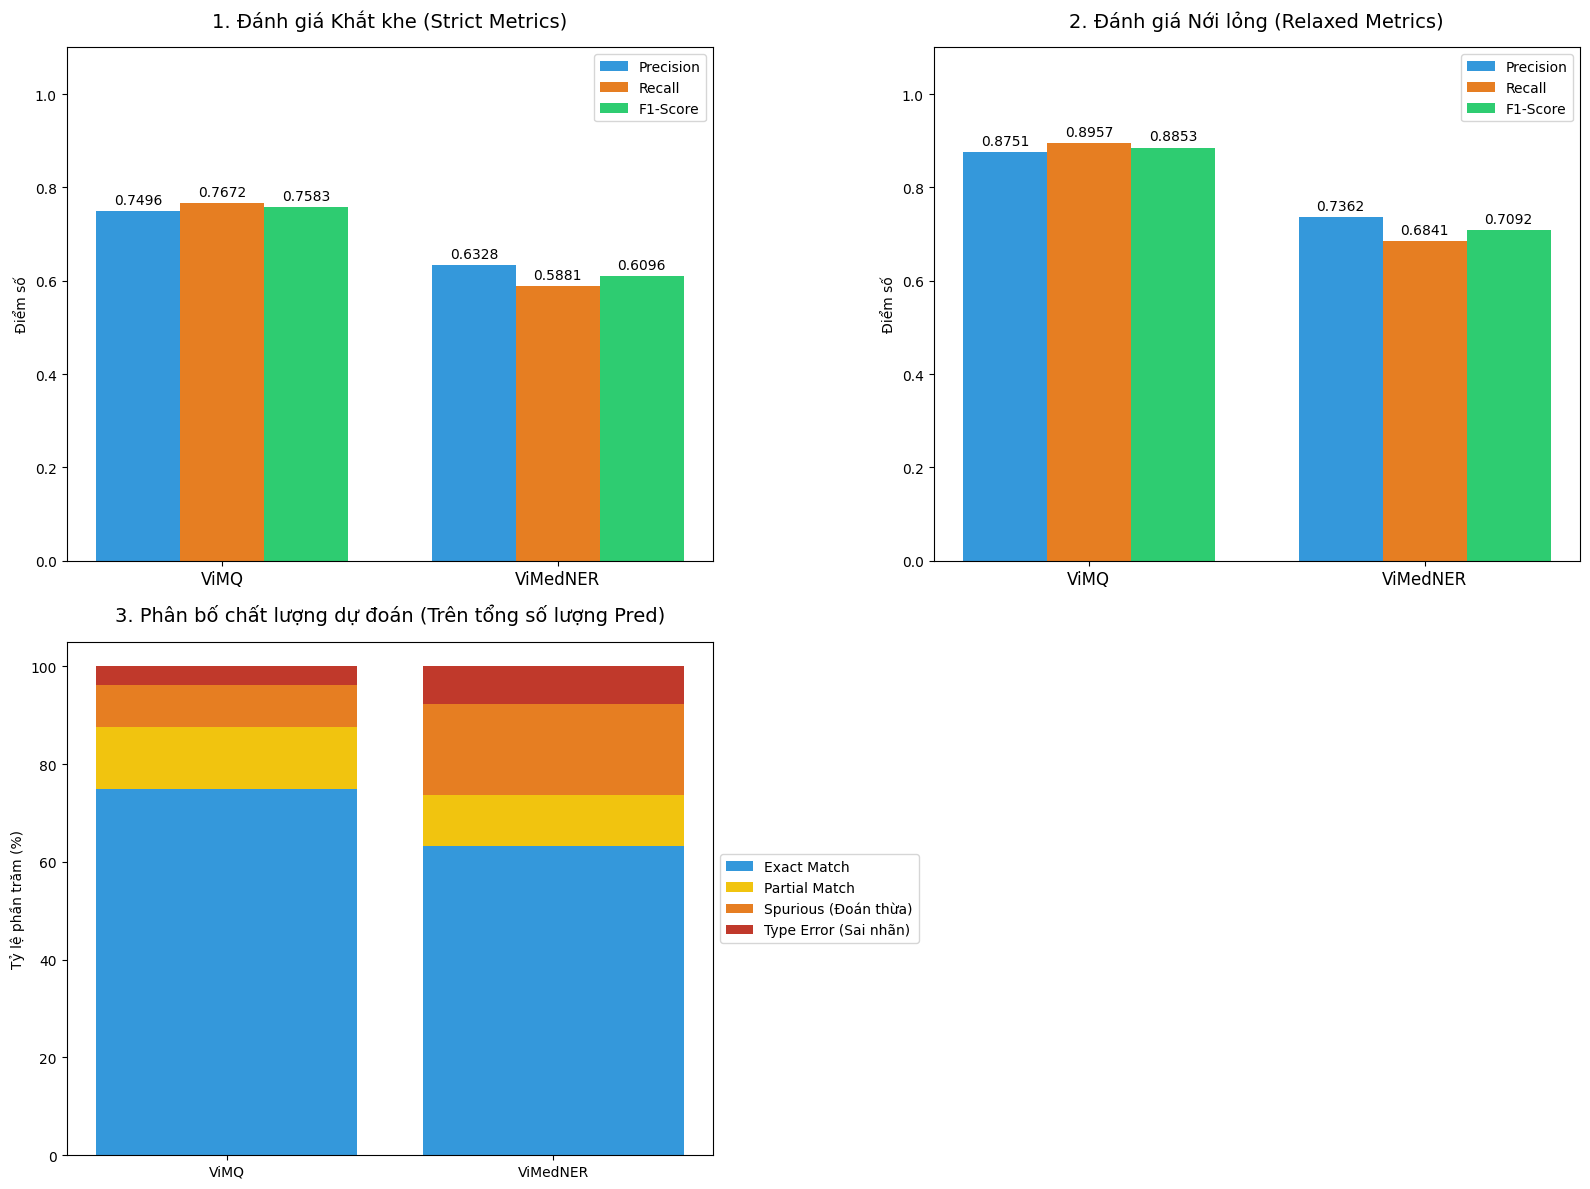

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. DỮ LIỆU ĐẦU VÀO
# ==========================================
datasets = ['ViMQ', 'ViMedNER']

# Dữ liệu Khắt khe (Strict)
strict_p = [0.7496, 0.6328]
strict_r = [0.7672, 0.5881]
strict_f1 = [0.7583, 0.6096]

# Dữ liệu Nới lỏng (Relaxed)
relaxed_p = [0.8751, 0.7362]
relaxed_r = [0.8957, 0.6841]
relaxed_f1 = [0.8853, 0.7092]

# Dữ liệu thống kê lỗi
total_pred_vimq = 1368 + 229 + 159 + 69
total_pred_vimedner = 2087 + 341 + 614 + 256

exact_pct = [1368/total_pred_vimq*100, 2087/total_pred_vimedner*100]
partial_pct = [229/total_pred_vimq*100, 341/total_pred_vimedner*100]
spurious_pct = [159/total_pred_vimq*100, 614/total_pred_vimedner*100]
type_err_pct = [69/total_pred_vimq*100, 256/total_pred_vimedner*100]

# ==========================================
# 2. THIẾT LẬP VẼ BIỂU ĐỒ (2 hàng x 2 cột)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
x = np.arange(len(datasets))
width = 0.25  # Độ rộng của mỗi cột (vì có 3 cột P, R, F1 đứng cạnh nhau)

# Bảng màu
color_p = '#3498db'  # Xanh dương cho Precision
color_r = '#e67e22'  # Cam cho Recall
color_f1 = '#2ecc71' # Xanh lá cho F1-Score

# --- BIỂU ĐỒ 1: CHỈ SỐ KHẮT KHE (STRICT) ---
ax1 = axes[0, 0]
rects1_1 = ax1.bar(x - width, strict_p, width, label='Precision', color=color_p)
rects1_2 = ax1.bar(x, strict_r, width, label='Recall', color=color_r)
rects1_3 = ax1.bar(x + width, strict_f1, width, label='F1-Score', color=color_f1)

ax1.set_ylabel('Điểm số')
ax1.set_title('1. Đánh giá Khắt khe (Strict Metrics)', fontsize=14, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(datasets, fontsize=12)
ax1.set_ylim(0, 1.1)
ax1.legend()
ax1.bar_label(rects1_1, padding=3, fmt='%.4f')
ax1.bar_label(rects1_2, padding=3, fmt='%.4f')
ax1.bar_label(rects1_3, padding=3, fmt='%.4f')

# --- BIỂU ĐỒ 2: CHỈ SỐ NỚI LỎNG (RELAXED) ---
ax2 = axes[0, 1]
rects2_1 = ax2.bar(x - width, relaxed_p, width, label='Precision', color=color_p)
rects2_2 = ax2.bar(x, relaxed_r, width, label='Recall', color=color_r)
rects2_3 = ax2.bar(x + width, relaxed_f1, width, label='F1-Score', color=color_f1)

ax2.set_ylabel('Điểm số')
ax2.set_title('2. Đánh giá Nới lỏng (Relaxed Metrics)', fontsize=14, pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(datasets, fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.legend()
ax2.bar_label(rects2_1, padding=3, fmt='%.4f')
ax2.bar_label(rects2_2, padding=3, fmt='%.4f')
ax2.bar_label(rects2_3, padding=3, fmt='%.4f')

# --- BIỂU ĐỒ 3: PHÂN BỐ LỖI CHẤT LƯỢNG (DSTACK BAR) ---
ax3 = axes[1, 0]
ax3.bar(datasets, exact_pct, label='Exact Match', color='#3498db')
ax3.bar(datasets, partial_pct, bottom=exact_pct, label='Partial Match', color='#f1c40f')
ax3.bar(datasets, spurious_pct, bottom=np.array(exact_pct)+np.array(partial_pct), label='Spurious (Đoán thừa)', color='#e67e22')
ax3.bar(datasets, type_err_pct, bottom=np.array(exact_pct)+np.array(partial_pct)+np.array(spurious_pct), label='Type Error (Sai nhãn)', color='#c0392b')

ax3.set_ylabel('Tỷ lệ phần trăm (%)')
ax3.set_title('3. Phân bố chất lượng dự đoán (Trên tổng số lượng Pred)', fontsize=14, pad=15)
ax3.legend(loc='center left', bbox_to_anchor=(1, 0.5)) # Đẩy legend ra ngoài cho đỡ che biểu đồ

# --- ẨN BIỂU ĐỒ THỨ 4 (Góc dưới bên phải) CHO ĐỠ TRỐNG ---
axes[1, 1].axis('off')

# Hiển thị
plt.tight_layout()
plt.show()

#Seqeval

In [ ]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=c50bd1df1143f9fbb8b44bf247160cb7a146121fb6efff3f6224395e4c7e6453
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
from pathlib import Path

VIMQ_GOLD_FILE = "/content/vimq_true_entities.jsonl"
VIMQ_PRED_FILE = "/content/vimq_pred_entities.jsonl"

VIMEDNER_GOLD_FILE = "/content/vimedner_true_entities-2 (1).jsonl"
VIMEDNER_PRED_FILE = "/content/vimedner_pred_entities-2 (1).jsonl"

OUTPUT_DIR = Path("/content/eval_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = [
    {
        "name": "vimq",
        "gold_path": Path(VIMQ_GOLD_FILE),
        "pred_path": Path(VIMQ_PRED_FILE),
    },
    {
        "name": "vimedner",
        "gold_path": Path(VIMEDNER_GOLD_FILE),
        "pred_path": Path(VIMEDNER_PRED_FILE),
    },
]

for item in DATASETS:
    print(item["name"])
    print("  gold:", item["gold_path"])
    print("  pred:", item["pred_path"])

vimq
  gold: /content/vimq_true_entities.jsonl
  pred: /content/vimq_pred_entities.jsonl
vimedner
  gold: /content/vimedner_true_entities-2 (1).jsonl
  pred: /content/vimedner_pred_entities-2 (1).jsonl


In [ ]:
import json
import re
from collections import Counter
from typing import List, Dict, Tuple

from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

def read_jsonl(path: Path) -> List[Dict]:
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def normalize_spaces(text: str) -> str:
    return re.sub(r'\s+', ' ', text.strip())

def tokenize_vi(text: str) -> List[str]:
    text = normalize_spaces(text)
    return text.split(' ') if text else []

def normalize_label(label: str) -> str:
    return label.strip().upper().replace(' ', '_').replace('-', '_')

def build_bio_tags(tokens: List[str], entities: List[Dict]) -> Tuple[List[str], List[Dict], List[Dict]]:
    tags = ['O'] * len(tokens)
    occupied = [False] * len(tokens)
    overlaps = []
    out_of_range = []

    # Sửa lại lambda để ưu tiên lấy 'start' và 'end', nếu không có thì fallback về key cũ
    sorted_entities = sorted(
        entities,
        key=lambda e: (e.get('start', e.get('vi_start_token_idx', 10**9)),
                       e.get('end', e.get('vi_end_token_idx', 10**9)))
    )

    for ent in sorted_entities:
        # Lấy giá trị từ key mới, nếu không có thì thử key cũ
        start = ent.get('start', ent.get('vi_start_token_idx'))
        end = ent.get('end', ent.get('vi_end_token_idx'))
        label = normalize_label(ent.get('label', 'ENT'))

        if start is None or end is None or start < 0 or end < start or end >= len(tokens):
            out_of_range.append(ent)
            continue

        if any(occupied[i] for i in range(start, end + 1)):
            overlaps.append(ent)
            continue

        tags[start] = f'B-{label}'
        for i in range(start + 1, end + 1):
            tags[i] = f'I-{label}'
        for i in range(start, end + 1):
            occupied[i] = True

    return tags, overlaps, out_of_range

def compute_entity_metrics(gold_tags_all: List[List[str]], pred_tags_all: List[List[str]]):
    report = classification_report(gold_tags_all, pred_tags_all, output_dict=True, zero_division=0)

    per_type = {}
    for label, values in report.items():
        if label in {'micro avg', 'macro avg', 'weighted avg'}:
            continue
        if not isinstance(values, dict):
            continue
        per_type[label] = {
            'support_gold': int(values.get('support', 0)),
            'support_pred': 0,
            'precision': values.get('precision', 0.0),
            'recall': values.get('recall', 0.0),
            'f1': values.get('f1-score', 0.0),
        }

    gold_by_type = Counter()
    pred_by_type = Counter()
    tp_by_type = Counter()

    for gold_tags, pred_tags in zip(gold_tags_all, pred_tags_all):
        gold_spans = set()
        pred_spans = set()

        i = 0
        while i < len(gold_tags):
            tag = gold_tags[i]
            if tag == 'O' or '-' not in tag:
                i += 1
                continue
            prefix, label = tag.split('-', 1)
            if prefix not in ('B', 'I'):
                i += 1
                continue
            start = i
            i += 1
            while i < len(gold_tags) and gold_tags[i] == f'I-{label}':
                i += 1
            gold_spans.add((start, i - 1, label))

        i = 0
        while i < len(pred_tags):
            tag = pred_tags[i]
            if tag == 'O' or '-' not in tag:
                i += 1
                continue
            prefix, label = tag.split('-', 1)
            if prefix not in ('B', 'I'):
                i += 1
                continue
            start = i
            i += 1
            while i < len(pred_tags) and pred_tags[i] == f'I-{label}':
                i += 1
            pred_spans.add((start, i - 1, label))

        matched = gold_spans & pred_spans

        for _, _, label in gold_spans:
            gold_by_type[label] += 1
        for _, _, label in pred_spans:
            pred_by_type[label] += 1
        for _, _, label in matched:
            tp_by_type[label] += 1

    labels = sorted(set(gold_by_type) | set(pred_by_type) | set(per_type))
    for label in labels:
        if label not in per_type:
            per_type[label] = {
                'support_gold': 0,
                'support_pred': 0,
                'precision': 0.0,
                'recall': 0.0,
                'f1': 0.0,
            }
        per_type[label]['support_gold'] = gold_by_type[label]
        per_type[label]['support_pred'] = pred_by_type[label]

    tp = sum(tp_by_type.values())
    fp = sum(pred_by_type.values()) - tp
    fn = sum(gold_by_type.values()) - tp

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision': precision_score(gold_tags_all, pred_tags_all),
        'recall': recall_score(gold_tags_all, pred_tags_all),
        'f1': f1_score(gold_tags_all, pred_tags_all),
        'per_type': per_type,
    }


In [ ]:
def run_pipeline(dataset_config: Dict, output_dir: Path) -> Dict:
    name = dataset_config['name']
    gold_rows = read_jsonl(dataset_config['gold_path'])
    pred_rows = read_jsonl(dataset_config['pred_path'])

    used_n = min(len(gold_rows), len(pred_rows))

    conll_path = output_dir / f'{name}.conll'
    gold_bio_path = output_dir / f'{name}.gold.bio'
    pred_bio_path = output_dir / f'{name}.pred.bio'
    summary_path = output_dir / f'{name}.summary.json'

    gold_tags_all = []
    pred_tags_all = []
    mismatched_sentences = 0
    gold_overlap_skipped = 0
    pred_overlap_skipped = 0
    gold_out_of_range_skipped = 0
    pred_out_of_range_skipped = 0

    with conll_path.open('w', encoding='utf-8') as f_conll, \
         gold_bio_path.open('w', encoding='utf-8') as f_gold, \
         pred_bio_path.open('w', encoding='utf-8') as f_pred:

        for idx in range(used_n):
            gold_row = gold_rows[idx]
            pred_row = pred_rows[idx]

            gold_sentence = gold_row['vi_sentence']
            pred_sentence = pred_row['vi_sentence']

            if normalize_spaces(gold_sentence) != normalize_spaces(pred_sentence):
                mismatched_sentences += 1

            tokens = tokenize_vi(gold_sentence)

            gold_tags, gold_overlap, gold_oor = build_bio_tags(tokens, gold_row.get('entities', []))
            pred_tags, pred_overlap, pred_oor = build_bio_tags(tokens, pred_row.get('entities', []))

            gold_overlap_skipped += len(gold_overlap)
            pred_overlap_skipped += len(pred_overlap)
            gold_out_of_range_skipped += len(gold_oor)
            pred_out_of_range_skipped += len(pred_oor)

            gold_tags_all.append(gold_tags)
            pred_tags_all.append(pred_tags)

            for token, gold_tag, pred_tag in zip(tokens, gold_tags, pred_tags):
                f_conll.write(f'{token}\t{gold_tag}\t{pred_tag}\n')
                f_gold.write(f'{token}\t{gold_tag}\n')
                f_pred.write(f'{token}\t{pred_tag}\n')

            f_conll.write('\n')
            f_gold.write('\n')
            f_pred.write('\n')

    metrics = compute_entity_metrics(gold_tags_all, pred_tags_all)

    summary = {
        'dataset': name,
        'gold_file': str(dataset_config['gold_path']),
        'pred_file': str(dataset_config['pred_path']),
        'sentences_gold': len(gold_rows),
        'sentences_pred': len(pred_rows),
        'sentences_used': used_n,
        'mismatched_sentences': mismatched_sentences,
        'gold_overlap_skipped': gold_overlap_skipped,
        'pred_overlap_skipped': pred_overlap_skipped,
        'gold_out_of_range_skipped': gold_out_of_range_skipped,
        'pred_out_of_range_skipped': pred_out_of_range_skipped,
        'metrics': metrics,
        'output_files': {
            'conll': str(conll_path),
            'gold_bio': str(gold_bio_path),
            'pred_bio': str(pred_bio_path),
            'summary': str(summary_path),
        },
    }

    with summary_path.open('w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    return summary


In [ ]:
all_reports = {}

for dataset in DATASETS:
    report = run_pipeline(dataset, OUTPUT_DIR)
    all_reports[dataset['name']] = report

combined_report_path = OUTPUT_DIR / 'combined_report.json'
with combined_report_path.open('w', encoding='utf-8') as f:
    json.dump(all_reports, f, ensure_ascii=False, indent=2)

print('Saved:', combined_report_path)
for name, report in all_reports.items():
    m = report['metrics']
    print(f"[{name}] used={report['sentences_used']} mismatch={report['mismatched_sentences']} P={m['precision']:.4f} R={m['recall']:.4f} F1={m['f1']:.4f}")


Saved: /content/eval_outputs/combined_report.json
[vimq] used=1000 mismatch=0 P=0.7266 R=0.7753 F1=0.7502
[vimedner] used=1525 mismatch=0 P=0.6676 R=0.5673 F1=0.6133


In [ ]:
import pandas as pd

rows = []
for name, report in all_reports.items():
    m = report['metrics']
    rows.append({
        'dataset': name,
        'sentences_used': report['sentences_used'],
        'mismatched_sentences': report['mismatched_sentences'],
        'precision': m['precision'],
        'recall': m['recall'],
        'f1': m['f1'],
        'gold_overlap_skipped': report['gold_overlap_skipped'],
        'pred_overlap_skipped': report['pred_overlap_skipped'],
        'gold_out_of_range_skipped': report['gold_out_of_range_skipped'],
        'pred_out_of_range_skipped': report['pred_out_of_range_skipped'],
    })

df_summary = pd.DataFrame(rows)
df_summary


,dataset,sentences_used,mismatched_sentences,precision,recall,f1,gold_overlap_skipped,pred_overlap_skipped,gold_out_of_range_skipped,pred_out_of_range_skipped
0,vimq,1000,0,0.726649,0.775338,0.750204,0,4,0,0
1,vimedner,1525,0,0.667561,0.567266,0.613341,0,355,0,0


In [ ]:
def per_type_dataframe(report: Dict) -> pd.DataFrame:
    rows = []
    for label, values in report['metrics']['per_type'].items():
        rows.append({
            'label': label,
            'support_gold': values['support_gold'],
            'support_pred': values['support_pred'],
            'precision': values['precision'],
            'recall': values['recall'],
            'f1': values['f1'],
        })
    return pd.DataFrame(rows).sort_values(['f1', 'support_gold'], ascending=[False, False]).reset_index(drop=True)

for dataset_name, report in all_reports.items():
    print('=' * 80)
    print(dataset_name)
    display(per_type_dataframe(report))


vimq


,label,support_gold,support_pred,precision,recall,f1
0,SYMPTOM_AND_DISEASE,1419,1507,0.752488,0.799154,0.775120
1,MEDICAL_PROCEDURE,238,258,0.655039,0.710084,0.681452
2,DRUG,119,130,0.569231,0.621849,0.594378


vimedner


,label,support_gold,support_pred,precision,recall,f1
0,DISEASE,1892,1496,0.788770,0.623679,0.696576
1,DIAGNOSTIC,318,271,0.701107,0.597484,0.645161
2,TREATMENT,673,590,0.662712,0.580981,0.619161
3,SYMPTOM,755,725,0.531034,0.509934,0.520270
4,CAUSE,309,272,0.341912,0.300971,0.320138


In [ ]:
preview_path = OUTPUT_DIR / 'vimq.conll'
with preview_path.open('r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(line.rstrip())
        if i >= 39:
            break


Viêm	B-SYMPTOM_AND_DISEASE	B-SYMPTOM_AND_DISEASE
dạ	I-SYMPTOM_AND_DISEASE	I-SYMPTOM_AND_DISEASE
dày	I-SYMPTOM_AND_DISEASE	I-SYMPTOM_AND_DISEASE
,	O	O
rối	B-SYMPTOM_AND_DISEASE	B-SYMPTOM_AND_DISEASE
loạn	I-SYMPTOM_AND_DISEASE	I-SYMPTOM_AND_DISEASE
thần	I-SYMPTOM_AND_DISEASE	I-SYMPTOM_AND_DISEASE
kinh	I-SYMPTOM_AND_DISEASE	I-SYMPTOM_AND_DISEASE
thực	I-SYMPTOM_AND_DISEASE	I-SYMPTOM_AND_DISEASE
vật	I-SYMPTOM_AND_DISEASE	I-SYMPTOM_AND_DISEASE
,	O	O
gai	B-SYMPTOM_AND_DISEASE	B-SYMPTOM_AND_DISEASE
đôi	I-SYMPTOM_AND_DISEASE	I-SYMPTOM_AND_DISEASE
cột	I-SYMPTOM_AND_DISEASE	I-SYMPTOM_AND_DISEASE
sống	I-SYMPTOM_AND_DISEASE	I-SYMPTOM_AND_DISEASE
nên	O	O
sử	O	O
dụng	O	O
thuốc	O	O
như	O	O
thế	O	O
nào	O	O
?	O	O

Trẻ	O	O
10	O	O
tháng	O	O
bị	O	O
nổi	B-SYMPTOM_AND_DISEASE	B-SYMPTOM_AND_DISEASE
hạch	I-SYMPTOM_AND_DISEASE	I-SYMPTOM_AND_DISEASE
sau	O	O
tai	O	O
có	O	O
sao	O	O
không	O	O
?	O	O

Xuất	O	O
hiện	O	O
cục	B-SYMPTOM_AND_DISEASE	B-SYMPTOM_AND_DISEASE
